In [24]:
# %pip install scikit-learn
# %pip install nbconvert
# %jupyter nbconvert --to script test.ipynb

In [25]:
# scipy.ndimage.median_filter
import os
import yaml
import numpy as np
import cv2
import pyrealsense2 as rs
import matplotlib.pyplot as plt
import pprint
import open3d as o3d
from sklearn.cluster import DBSCAN
from ultralytics import YOLO
import torch

import INUVisionLib as ivl

print("\n라이브러리 로드")


라이브러리 로드


# **[시작] 카메라 호출**

### 카메라 설정

[mid_50] 모드로 카메라(ID: 327122072783) 구동을 시작합니다...
✅ Preset 설정 완료: High Density
✅ Depth Unit 설정 완료: 9.999999747378752e-05
✅ 뎁스 센서 자동 노출(AE) 스위치 ON
✅ Depth ROI 영역 설정 완료 (중앙 40% / X: 254~593, Y: 144~336)
✅ 레이저 파워 설정 완료: 250
✅ Disparity Shift 설정 완료: 0
✅ Temporal Filter 설정 완료
✅ Threshold Filter 설정 완료 (최소: 0.2m, 최대: 0.8m)
✅ 컬러 센서 자동 화이트 밸런스(AWB) ON
🔥 센서 안정화 중... (30 프레임 대기)


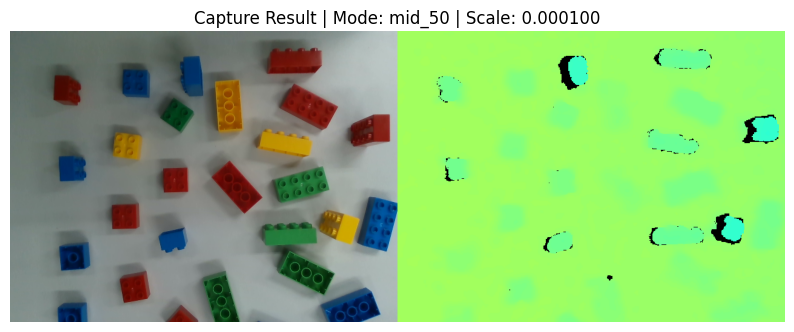

✅ 카메라 스트리밍 안전 종료 완료.


In [26]:
# 카메라 연결 확인
devices = ivl.get_realsense_ids()
target_serial = list(devices.keys())[0]

# 8비트 RGB 이미지, 16비트 뎁스, 인트린직, 뎁스 스케일 출력
# 카메라 모드 별로 설정 변경 가능

color_rgb, depth, intrinsics, scale = ivl.capture_realsense_data(
    serial_number=target_serial, 
    mode="mid_50", 
    visualize=True
)

color_img_bgr = color_rgb.copy()
color_img_bgr = cv2.cvtColor(color_img_bgr, cv2.COLOR_RGB2BGR)

# color_img_rgb (ndarray): RGB 포맷의 컬러 이미지 (YOLO, Open3D용)
# depth_img (ndarray): Raw 뎁스 이미지
# intrinsics (rs.intrinsics): 카메라 내부 파라미터 (3D 투영용)
# depth_scale (float): 뎁스 단위를 미터(m)로 변환하기 위한 스케일 값 (매우 중요)

# **욜로 인지**

### **YOLO V8 세그멘테이션 기준 영역 잡기**

🎯 [SUCCESS] 27개의 타겟 객체 마스크 병합 완료


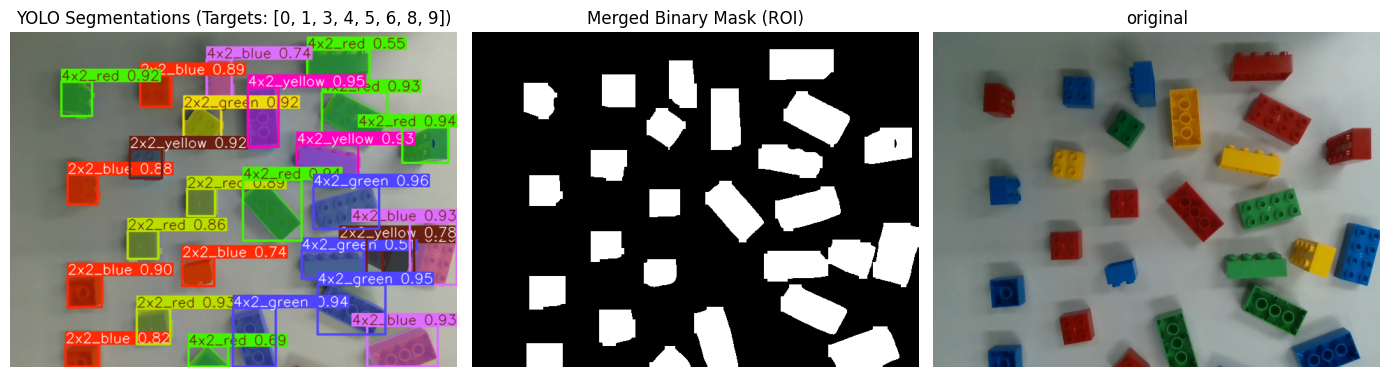

In [27]:
# color_rgb, depth, intrinsics, scale

# 욜로 검출
model = YOLO("yolo_models/duplo_2_low_2/weights/best.pt")
# model = YOLO("yolo_models/manip_segmentor_0528.pt")
target_classes = [0, 1, 3, 4, 5, 6, 8, 9]

results, mask_binary, vis_yolo = ivl.detect_objects_yolo(
    model= model, 
    color_img_bgr=color_img_bgr, 
    target_classes=target_classes, 
    visualize=True
)

# results (list): YOLO 모델의 원본 추론 결과 객체 리스트
# mask_binary (ndarray): 검출된 모든 객체의 마스크를 하나로 합친 이진 마스크 (0 or 1, 형태: H x W)
# vis_yolo (ndarray): 바운딩 박스와 라벨이 그려진 시각화용 이미지 (BGR)

### 바운딩 박스가 겹치는 부분을 억제하는 전처리 추가

✂️ [INFO] 억제됨: '2x2_yellow' (면적:1838)가 '2x2_yellow' (면적:2834)에 97.9% 포함됨.

✅ 최종 검출된 유효 객체/군집 수: 26개
 - 🏷️ 4x2_blue (신뢰도: 0.93)
 - 🏷️ 4x2_red (신뢰도: 0.93)
 - 🏷️ 4x2_blue (신뢰도: 0.93)
 - 🏷️ 4x2_green (신뢰도: 0.96)
 - 🏷️ 4x2_green (신뢰도: 0.94)
 - 🏷️ 4x2_green (신뢰도: 0.95)
 - 🏷️ 4x2_red (신뢰도: 0.94)
 - 🏷️ 4x2_red (신뢰도: 0.55)
 - 🏷️ 4x2_yellow (신뢰도: 0.95)
 - 🏷️ 4x2_green (신뢰도: 0.51)
 - 🏷️ 4x2_yellow (신뢰도: 0.93)
 - 🏷️ 4x2_red (신뢰도: 0.94)
 - 🏷️ 2x2_yellow (신뢰도: 0.78)
 - 🏷️ 4x2_blue (신뢰도: 0.74)
 - 🏷️ 2x2_red (신뢰도: 0.93)
 - 🏷️ 2x2_blue (신뢰도: 0.90)
 - 🏷️ 2x2_blue (신뢰도: 0.89)
 - 🏷️ 2x2_yellow (신뢰도: 0.92)
 - 🏷️ 2x2_green (신뢰도: 0.92)
 - 🏷️ 4x2_red (신뢰도: 0.92)
 - 🏷️ 2x2_blue (신뢰도: 0.88)
 - 🏷️ 2x2_red (신뢰도: 0.86)
 - 🏷️ 2x2_blue (신뢰도: 0.82)
 - 🏷️ 2x2_red (신뢰도: 0.89)
 - 🏷️ 2x2_blue (신뢰도: 0.74)
 - 🏷️ 4x2_red (신뢰도: 0.69)


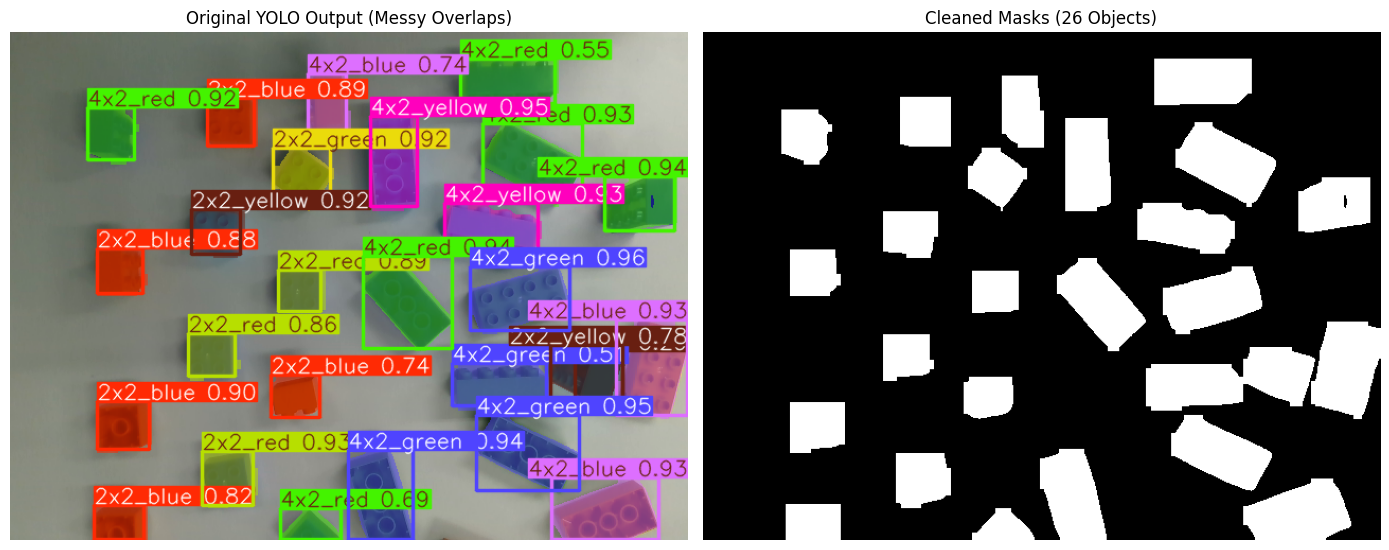


✅ 최종 검출된 유효 객체/군집 수: 26개
 - Name: 4x2_blue
 - Name: 4x2_red
 - Name: 4x2_blue
 - Name: 4x2_green
 - Name: 4x2_green
 - Name: 4x2_green
 - Name: 4x2_red
 - Name: 4x2_red
 - Name: 4x2_yellow
 - Name: 4x2_green
 - Name: 4x2_yellow
 - Name: 4x2_red
 - Name: 2x2_yellow
 - Name: 4x2_blue
 - Name: 2x2_red
 - Name: 2x2_blue
 - Name: 2x2_blue
 - Name: 2x2_yellow
 - Name: 2x2_green
 - Name: 4x2_red
 - Name: 2x2_blue
 - Name: 2x2_red
 - Name: 2x2_blue
 - Name: 2x2_red
 - Name: 2x2_blue
 - Name: 4x2_red


In [28]:
# 겹치는 마스크 깔끔하게 정리 (해상도 640x480 기준, 70% 겹치면 삭제, 시각화 켬)
final_objects, clean_mask = ivl.filter_overlapping_masks(
    results=results, 
    overlap_threshold=0.70, 
    img_shape=(640, 480), 
    visualize=True
)

# final_detected_objects (list): 억제 후 살아남은 최종 객체들의 리스트. 
#                                 각 요소는 dict 형태 (class_id, class_name, confidence, mask)
# final_combined_mask (ndarray): 병합된 최종 전체 ROI 마스크 (0 or 1, uint8)

print(f"\n✅ 최종 검출된 유효 객체/군집 수: {len(final_objects)}개")
final_combined_mask = np.zeros((480, 640), dtype=np.uint8)
for obj in final_objects:
    print(f" - Name: {obj['class_name']}")
    final_combined_mask = np.logical_or(final_combined_mask, obj["mask"]).astype(np.uint8)

### Ransac 바닥 검출 후 높이 + 비율 기반 ID 수정

In [29]:
import copy

# 1. 이전 단계에서 얻은 데이터: 
# color_rgb, depth, intrinsics, scale
# final_objects, clean_mask

# =================================================================
# [STEP 1 & 2 통합] DBSCAN+RANSAC 바닥 추정 및 40mm 돌출 맵 사영
# =================================================================
# 기존의 바닥 다림질과 돌출 맵 추출 과정이 하나의 함수로 처리됩니다.
# 반환된 closed_mask가 곧 40mm 이상 돌출된 객체의 2D 마스크(mask_40mm_2d)입니다.
mask_40mm_2d, refined_color, contours, plane_model = ivl.extract_3d_protruding_objects(
    depth_img=depth, 
    color_img_bgr=color_img_bgr, 
    intrinsics=intrinsics, 
    depth_scale=scale, 
    yolo_combined_mask=clean_mask,
    depth_trunc=5.0,
    height_threshold=0.040,
    visualize=False
)

# print(f"\n✅ 최종 검출된 유효 객체/군집 수: {len(final_objects)}개")
# final_combined_mask = np.zeros((480, 640), dtype=np.uint8)
# for obj in final_objects:
#     print(f" - Name: {obj['class_name']}")
#     final_combined_mask = np.logical_or(final_combined_mask, obj["mask"]).astype(np.uint8)

# =================================================================
# [STEP 3] 최종 OBB 기반 ID 판독 및 교정
# =================================================================

final_objects_before = copy.deepcopy(final_objects)

final_objects, result_vis_img = ivl.correct_object_ids(
    detected_objects=final_objects, 
    mask_high_2d=mask_40mm_2d, 
    color_img_bgr=color_img_bgr, 
    ratio_threshold=1.5, 
    overlap_threshold=0.20, 
    visualize=False
)

final_objects_after = copy.deepcopy(final_objects)

final_objects_after = ivl.add_side2_suffix_for_high_corrected_objects(
    objects_before=final_objects_before,
    objects_after=final_objects_after,
    mask_40mm_2d=mask_40mm_2d,
    overlap_threshold=0.20,
    only_changed=False,      # ID가 바뀐 객체만 _side2
    remove_c_prefix=False
)

for i, obj in enumerate(final_objects_after):
    print(i, obj.keys())
    print("class:", obj["class_name"])
    print("mask shape:", obj["mask"].shape, "dtype:", obj["mask"].dtype, "unique:", np.unique(obj["mask"])[:10])
    print()

# =================================================================
# [STEP 3-1] ID 교정 후 마스크 내부 채우기
# =================================================================

objects_filled = copy.deepcopy(final_objects_after)

mask_before = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)
mask_after = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)

for obj in objects_filled:
    original_mask = (obj["mask"] > 0).astype(np.uint8)

    filled_mask = ivl.fill_object_mask_holes(original_mask)

    obj["mask"] = filled_mask.astype(bool)

    mask_before = np.logical_or(mask_before, original_mask > 0).astype(np.uint8)
    mask_after = np.logical_or(mask_after, filled_mask > 0).astype(np.uint8)


# =================================================================
# [STEP 3-1] ID 교정 후 마스크 Convex Hull로 내부 채우기
# =================================================================

objects_hull = copy.deepcopy(objects_filled)

mask_before = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)
mask_hull_after = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)

for obj in objects_hull:
    original_mask = (obj["mask"] > 0).astype(np.uint8)

    # Convex Hull로 객체 영역 재생성
    hull_mask = ivl.fill_object_mask_by_convex_hull(
        original_mask,
        min_area=20
    )

    # 객체별 mask를 hull 결과로 교체
    obj["mask"] = hull_mask.astype(bool)

    # 전체 before / after 통합 마스크
    mask_before = np.logical_or(mask_before, original_mask > 0).astype(np.uint8)
    mask_hull_after = np.logical_or(mask_hull_after, hull_mask > 0).astype(np.uint8)



[INFO] 3D 기반 돌출 객체 추출 및 2D 마스킹 파이프라인 시작...
✅ 바닥 평면 도출 성공: 0.018x + -0.001y + 1.000z + 0.494 = 0
✅ 40.0mm 이상 돌출된 객체 포인트: 340개

[INFO] 객체 마스크 기반 OBB 추출 및 물리적 조건 기반 ID 교정 중...
 ⚠️ [높이 교정] 쌓인 블록 감지! '2x2_yellow' -> '4x2_yellow'
 🔍 [비율 교정] 짧은 블록 감지 (비율:1.09). '4x2_red' -> '2x2_red'
 🧱 [SIDE2 부여] index 11: 4x2_red -> 4x2_red_side2 (overlap=0.544)
 🧱 [SIDE2 부여] index 12: 2x2_yellow -> 4x2_yellow_side2 (overlap=0.426)
 🧱 [SIDE2 부여] index 13: 4x2_blue -> 4x2_blue_side2 (overlap=0.530)
0 dict_keys(['class_id', 'class_name', 'confidence', 'mask', 'is_side2', 'height_overlap_ratio'])
class: 4x2_blue
mask shape: (480, 640) dtype: bool unique: [False  True]

1 dict_keys(['class_id', 'class_name', 'confidence', 'mask', 'is_side2', 'height_overlap_ratio'])
class: 4x2_red
mask shape: (480, 640) dtype: bool unique: [False  True]

2 dict_keys(['class_id', 'class_name', 'confidence', 'mask', 'is_side2', 'height_overlap_ratio'])
class: 4x2_blue
mask shape: (480, 640) dtype: bool unique: [False  True]

3 d

### 디버깅용 - 어떤 객체가 변경되었는지 하이라이트


[ID 변경 목록]
 - index 11: 4x2_red -> 4x2_red_side2
 - index 12: 2x2_yellow -> 4x2_yellow_side2
 - index 13: 4x2_blue -> 4x2_blue_side2
 - index 19: 4x2_red -> 2x2_red


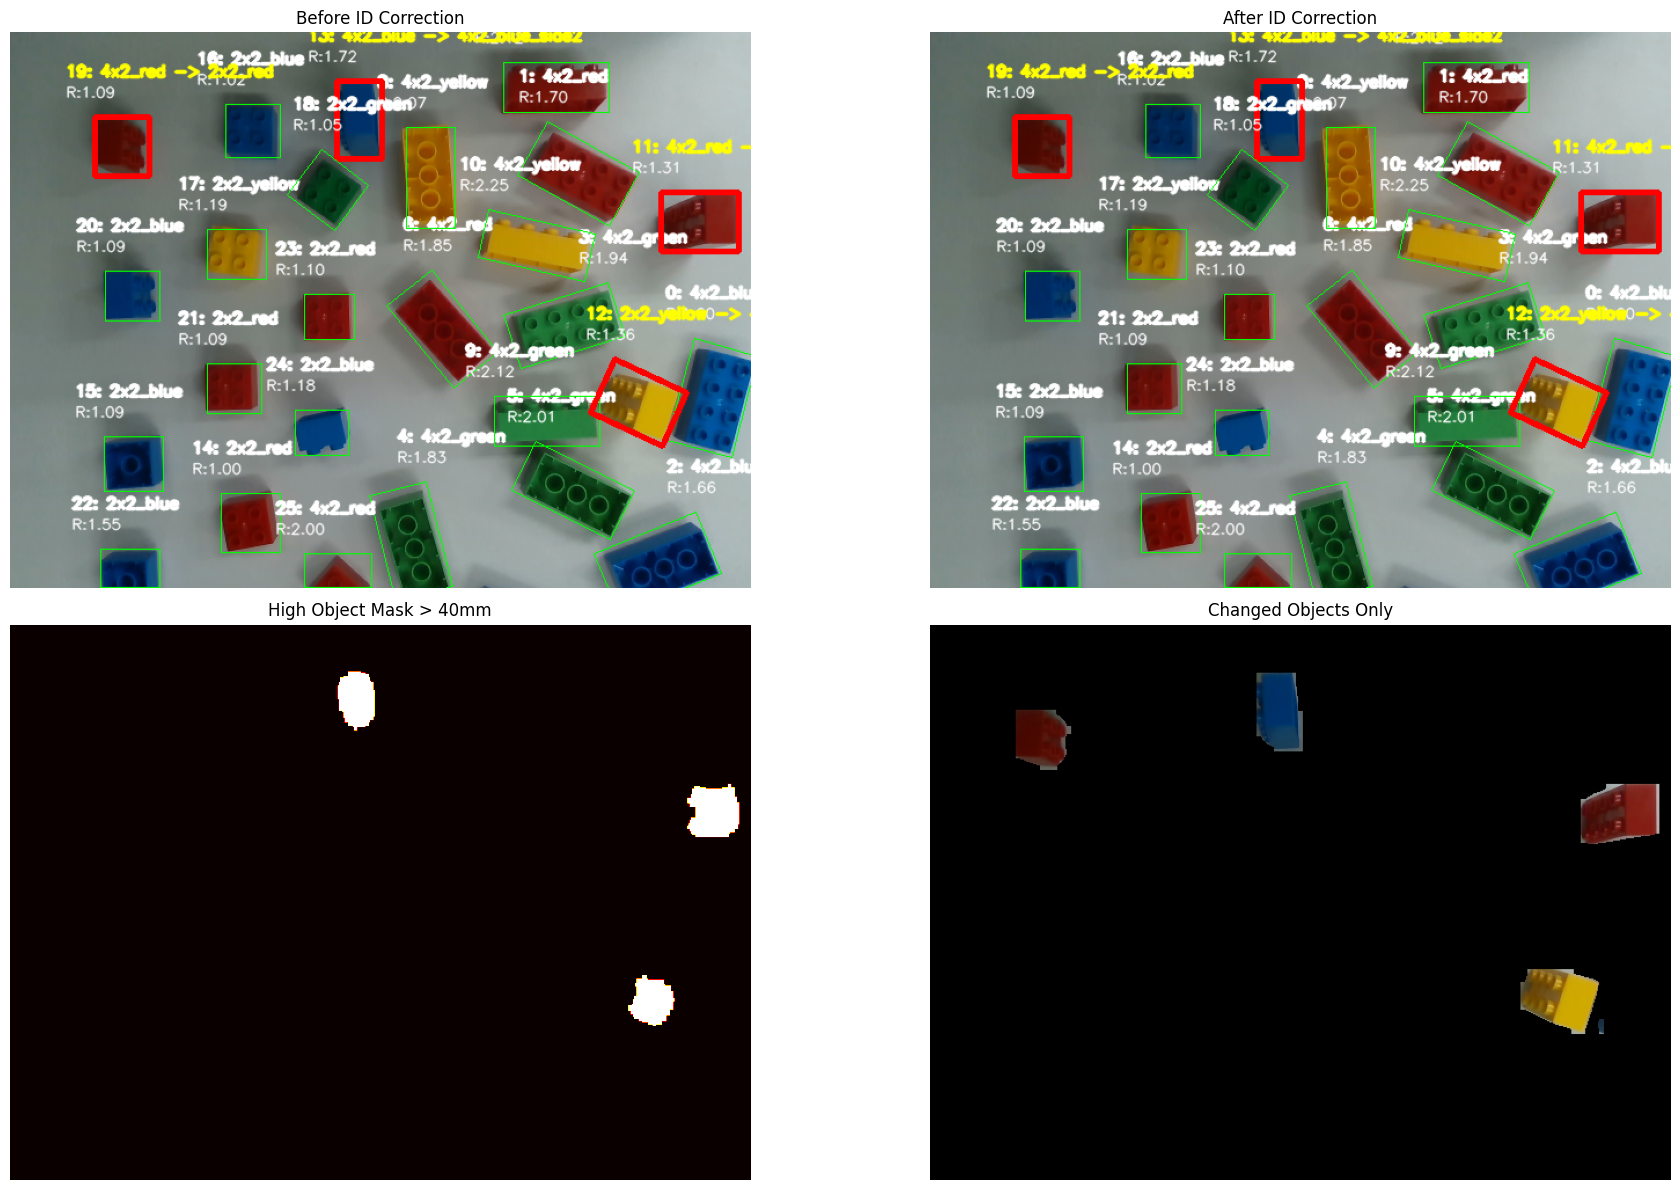

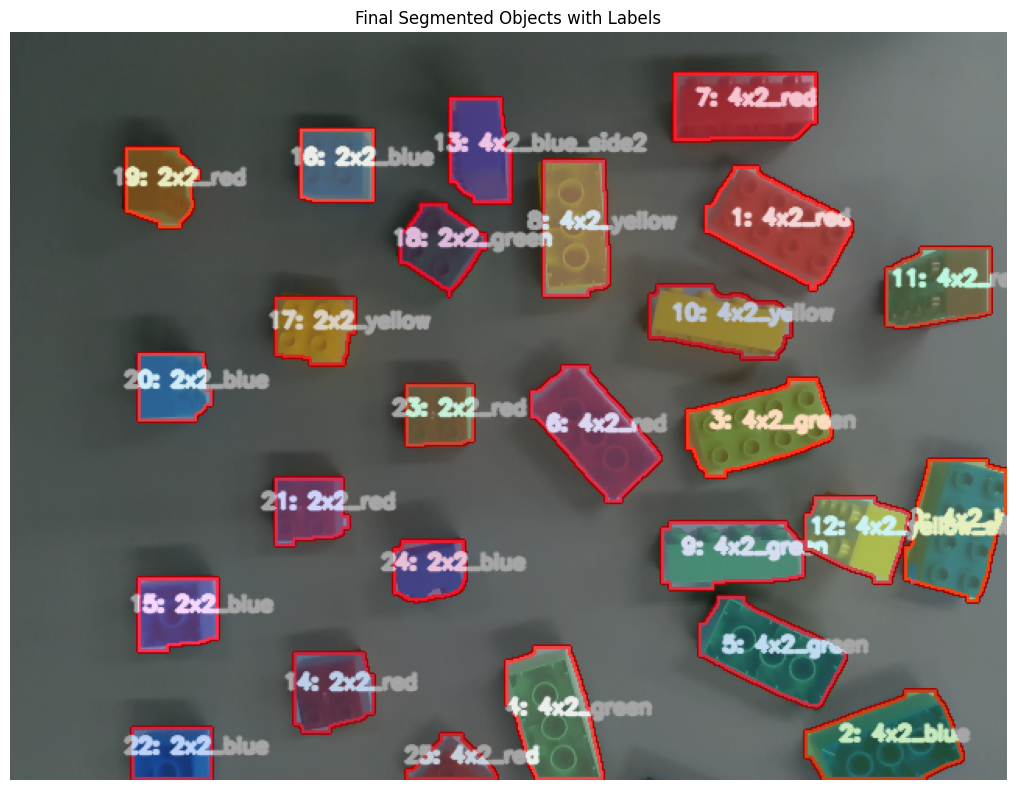

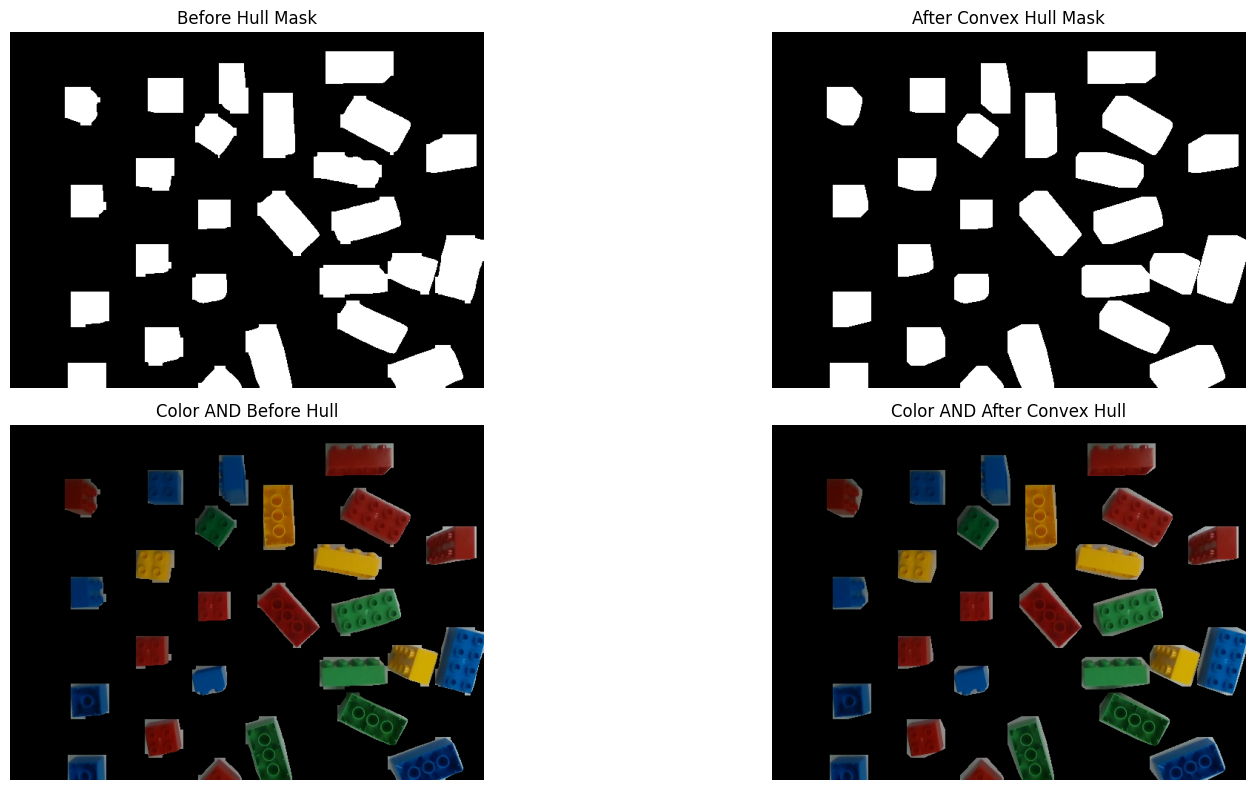

In [30]:
vis_result = ivl.visualize_id_correction_and_final_segments(
    color_img_bgr=color_img_bgr,
    final_objects_before=final_objects_before,
    final_objects_after=objects_filled,
    mask_40mm_2d=mask_40mm_2d,
    mask_before = mask_before,
    mask_hull_after = mask_hull_after,
    show=True
)

### 상하측면 구분 하기

4*2 세워진거 없애고,

욜로 영역 빼고 전부 비활성화 한다음에

대비랑 조도 만지고,

허프 서클 검출해서

원 몇개인지 보고, 이거 전부 선으로 잇는데,

원들이 하나의 점이나, 세개가 이어져서 선으로만 끝나면 아랫면,

적어도 하나의 끝나는 면이 있다면, 닫힌 부분의 면이 생성되면 윗면,



In [31]:
# =================================================================
# [STEP 3-2] side2 객체를 제외한 Convex Hull 마스크 생성
# =================================================================

mask_no_side2 = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)
mask_side2_only = np.zeros(color_img_bgr.shape[:2], dtype=np.uint8)

objects_no_side2 = []
objects_side2 = []

for idx, obj in enumerate(objects_hull):
    class_name = obj["class_name"]
    obj_mask = (obj["mask"] > 0).astype(np.uint8)

    if "side2" in class_name:
        objects_side2.append(obj)
        mask_side2_only = np.logical_or(mask_side2_only, obj_mask > 0).astype(np.uint8)
        print(f"[REMOVE side2] idx {idx}: {class_name}")
    else:
        objects_no_side2.append(obj)
        mask_no_side2 = np.logical_or(mask_no_side2, obj_mask > 0).astype(np.uint8)
        print(f"[KEEP] idx {idx}: {class_name}")

mask_no_side2_255 = (mask_no_side2 * 255).astype(np.uint8)

color_no_side2_bgr = cv2.bitwise_and(
    color_img_bgr,
    color_img_bgr,
    mask=mask_no_side2_255
)

[KEEP] idx 0: 4x2_blue
[KEEP] idx 1: 4x2_red
[KEEP] idx 2: 4x2_blue
[KEEP] idx 3: 4x2_green
[KEEP] idx 4: 4x2_green
[KEEP] idx 5: 4x2_green
[KEEP] idx 6: 4x2_red
[KEEP] idx 7: 4x2_red
[KEEP] idx 8: 4x2_yellow
[KEEP] idx 9: 4x2_green
[KEEP] idx 10: 4x2_yellow
[REMOVE side2] idx 11: 4x2_red_side2
[REMOVE side2] idx 12: 4x2_yellow_side2
[REMOVE side2] idx 13: 4x2_blue_side2
[KEEP] idx 14: 2x2_red
[KEEP] idx 15: 2x2_blue
[KEEP] idx 16: 2x2_blue
[KEEP] idx 17: 2x2_yellow
[KEEP] idx 18: 2x2_green
[KEEP] idx 19: 2x2_red
[KEEP] idx 20: 2x2_blue
[KEEP] idx 21: 2x2_red
[KEEP] idx 22: 2x2_blue
[KEEP] idx 23: 2x2_red
[KEEP] idx 24: 2x2_blue
[KEEP] idx 25: 4x2_red


In [36]:
import cv2
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt
from matplotlib import cm


def build_floor_scene_data_from_depth(
    depth_img,
    intrinsics,
    depth_scale,
    object_mask_01,
    depth_trunc=5.0,
    voxel_size=0.003,
    plane_dist_thresh=0.015,
    floor_height_eps=0.005,
    visualize=False
):
    """
    Convex Hull 등으로 만든 객체 마스크를 제외하고 바닥 RANSAC을 다시 수행.
    이후 전체 point cloud에 대해 signed_height를 계산하고,
    바닥 포인트는 plane 위로 투영해서 매끈한 floor_pcd를 생성.

    Returns:
        pcd_data:
            {
                "points": 전체 points,
                "signed_height": 바닥 기준 signed height,
                "valid_uv": (u_all, v_all, valid_idx)
            }

        plane_data:
            {
                "normal": 객체 방향으로 향하는 plane normal,
                "d": plane equation d,
                "plane_model": (a,b,c,d)
            }

        floor_pcd:
            바닥으로 판정된 점들을 plane 위에 투영한 Open3D point cloud
    """

    print("\n[INFO] Convex Hull 객체 마스크 제외 후 바닥 평면 재추정 중...")

    h, w = depth_img.shape[:2]

    object_mask_01 = (object_mask_01 > 0).astype(np.uint8)

    # 객체 영역 확장해서 바닥 추정에서 제외
    kernel = np.ones((7, 7), np.uint8)
    expanded_obj_mask = cv2.dilate(object_mask_01, kernel, iterations=3)

    filtered_depth = cv2.medianBlur(depth_img, 5)

    bg_depth = filtered_depth.copy()
    bg_depth[expanded_obj_mask > 0] = 0

    o3d_intr = o3d.camera.PinholeCameraIntrinsic(
        int(intrinsics.width),
        int(intrinsics.height),
        float(intrinsics.fx),
        float(intrinsics.fy),
        float(intrinsics.ppx),
        float(intrinsics.ppy)
    )

    o3d_depth_scale = 1.0 / float(depth_scale)

    # ------------------------------------------------------------
    # 1. 바닥 후보 point cloud
    # ------------------------------------------------------------
    bg_depth_o3d = o3d.geometry.Image(bg_depth)

    bg_pcd = o3d.geometry.PointCloud.create_from_depth_image(
        bg_depth_o3d,
        o3d_intr,
        depth_scale=o3d_depth_scale,
        depth_trunc=depth_trunc
    )

    bg_pcd = bg_pcd.voxel_down_sample(voxel_size=voxel_size)

    if len(bg_pcd.points) < 30:
        raise RuntimeError(f"바닥 후보 포인트가 너무 적습니다: {len(bg_pcd.points)}")

    bg_pcd, _ = bg_pcd.remove_statistical_outlier(
        nb_neighbors=20,
        std_ratio=2.0
    )

    if len(bg_pcd.points) < 3:
        raise RuntimeError("RANSAC 수행 가능한 바닥 포인트가 부족합니다.")

    # ------------------------------------------------------------
    # 2. RANSAC plane
    # ------------------------------------------------------------
    raw_plane_model, inliers = bg_pcd.segment_plane(
        distance_threshold=plane_dist_thresh,
        ransac_n=3,
        num_iterations=1000
    )

    a, b, c, d = raw_plane_model
    n_raw = np.array([a, b, c], dtype=np.float64)
    norm = np.linalg.norm(n_raw)

    if norm < 1e-9:
        raise RuntimeError("RANSAC plane normal이 비정상입니다.")

    n_raw = n_raw / norm
    d_raw = d / norm

    # ------------------------------------------------------------
    # 3. 전체 point cloud
    # ------------------------------------------------------------
    full_depth_o3d = o3d.geometry.Image(filtered_depth)

    full_pcd = o3d.geometry.PointCloud.create_from_depth_image(
        full_depth_o3d,
        o3d_intr,
        depth_scale=o3d_depth_scale,
        depth_trunc=depth_trunc
    )

    full_pcd = full_pcd.voxel_down_sample(voxel_size=voxel_size)

    points = np.asarray(full_pcd.points)

    if len(points) == 0:
        raise RuntimeError("전체 point cloud가 비어 있습니다.")

    # ------------------------------------------------------------
    # 4. 3D point -> 2D pixel projection
    # ------------------------------------------------------------
    z_safe = np.where(points[:, 2] == 0, 1e-6, points[:, 2])

    u_all = np.round((points[:, 0] * intrinsics.fx / z_safe) + intrinsics.ppx).astype(int)
    v_all = np.round((points[:, 1] * intrinsics.fy / z_safe) + intrinsics.ppy).astype(int)

    valid_idx = (
        (u_all >= 0) & (u_all < w) &
        (v_all >= 0) & (v_all < h)
    )

    # ------------------------------------------------------------
    # 5. normal 방향 선택
    #    객체 마스크 내부 포인트들의 height가 양수가 되도록 normal 방향 결정
    # ------------------------------------------------------------
    u_valid = u_all[valid_idx]
    v_valid = v_all[valid_idx]
    points_valid = points[valid_idx]

    in_obj = object_mask_01[v_valid, u_valid] > 0

    h1 = np.dot(points_valid, n_raw) + d_raw
    h2 = np.dot(points_valid, -n_raw) - d_raw

    if np.count_nonzero(in_obj) > 10:
        score1 = np.percentile(h1[in_obj], 90)
        score2 = np.percentile(h2[in_obj], 90)

        if score2 > score1:
            plane_normal = -n_raw
            plane_d = -d_raw
        else:
            plane_normal = n_raw
            plane_d = d_raw
    else:
        # 객체 포인트가 부족하면 카메라 방향 기준으로 normal z가 음수가 되게 설정
        # top-down RealSense 기준: 객체 돌출 방향은 대체로 -Z
        if n_raw[2] > 0:
            plane_normal = -n_raw
            plane_d = -d_raw
        else:
            plane_normal = n_raw
            plane_d = d_raw

    signed_height = np.dot(points, plane_normal) + plane_d

    print(
        f"✅ Plane: "
        f"{plane_normal[0]:.4f}x + {plane_normal[1]:.4f}y + "
        f"{plane_normal[2]:.4f}z + {plane_d:.4f} = 0"
    )

    # ------------------------------------------------------------
    # 6. 매끈한 바닥 point cloud 생성
    # ------------------------------------------------------------
    floor_indices = np.where(np.abs(signed_height) <= floor_height_eps)[0]

    floor_points = points[floor_indices]

    if len(floor_points) > 0:
        floor_dist = np.dot(floor_points, plane_normal) + plane_d
        floor_points_flat = floor_points - np.outer(floor_dist, plane_normal)

        floor_pcd = o3d.geometry.PointCloud()
        floor_pcd.points = o3d.utility.Vector3dVector(floor_points_flat)
        floor_pcd.paint_uniform_color([0.75, 0.75, 0.75])
    else:
        floor_pcd = None
        print("⚠️ floor_pcd 생성용 바닥 포인트가 부족합니다.")

    pcd_data = {
        "points": points,
        "signed_height": signed_height,
        "u_all": u_all,
        "v_all": v_all,
        "valid_idx": valid_idx
    }

    plane_data = {
        "normal": plane_normal,
        "d": plane_d,
        "plane_model": (
            float(plane_normal[0]),
            float(plane_normal[1]),
            float(plane_normal[2]),
            float(plane_d)
        )
    }

    if visualize:
        geoms = []
        if floor_pcd is not None:
            geoms.append(floor_pcd)

        inlier_cloud = bg_pcd.select_by_index(inliers)
        inlier_cloud.paint_uniform_color([0.2, 0.8, 0.2])
        geoms.append(inlier_cloud)

        o3d.visualization.draw_geometries(
            geoms,
            window_name="Re-estimated Smooth Floor"
        )

    return pcd_data, plane_data, floor_pcd

def project_pixel_to_plane(u, v, intrinsics, plane_normal, plane_d):
    """
    픽셀 좌표 u,v에서 나가는 camera ray와 plane의 교점을 계산.
    Open3D camera coordinate 기준.
    """
    x = (u - intrinsics.ppx) / intrinsics.fx
    y = (v - intrinsics.ppy) / intrinsics.fy
    ray = np.array([x, y, 1.0], dtype=np.float64)

    denom = np.dot(plane_normal, ray)

    if abs(denom) < 1e-9:
        return None

    t = -plane_d / denom

    if t <= 0:
        return None

    return ray * t


def create_floor_anchored_box_lineset(
    box_2d,
    intrinsics,
    plane_normal,
    plane_d,
    height,
    color=(1.0, 0.0, 0.0)
):
    """
    2D minAreaRect box 4점을 바닥 plane에 투영한 뒤,
    plane_normal 방향으로 height만큼 올려 3D OBB line set 생성.

    Returns:
        line_set
        center_3d
        floor_center_3d
        corners_3d
    """

    floor_corners = []

    for p in box_2d:
        u, v = int(p[0]), int(p[1])
        p3d = project_pixel_to_plane(
            u,
            v,
            intrinsics,
            plane_normal,
            plane_d
        )

        if p3d is None:
            return None, None, None, None

        floor_corners.append(p3d)

    floor_corners = np.asarray(floor_corners, dtype=np.float64)

    top_corners = floor_corners + plane_normal.reshape(1, 3) * float(height)

    corners = np.vstack([floor_corners, top_corners])

    lines = [
        [0, 1], [1, 2], [2, 3], [3, 0],
        [4, 5], [5, 6], [6, 7], [7, 4],
        [0, 4], [1, 5], [2, 6], [3, 7]
    ]

    colors = [color for _ in lines]

    line_set = o3d.geometry.LineSet()
    line_set.points = o3d.utility.Vector3dVector(corners)
    line_set.lines = o3d.utility.Vector2iVector(lines)
    line_set.colors = o3d.utility.Vector3dVector(colors)

    floor_center = np.mean(floor_corners, axis=0)
    center_3d = floor_center + plane_normal * (float(height) * 0.5)

    return line_set, center_3d, floor_center, corners

def generate_3d_obbs_from_hull_objects(
    objects,
    refined_mask_01,
    pcd_data,
    plane_data,
    intrinsics,
    color_img_rgb,
    floor_pcd=None,
    min_height=0.024,
    max_height_limit=0.12,
    height_percentile=95,
    visualize_2d=True
):
    """
    이미 ID 교정 + side2 처리 + Convex Hull 적용이 끝난 objects를 기준으로
    floor anchored 3D OBB 생성.

    objects:
        objects_hull 또는 objects_no_side2

    refined_mask_01:
        mask_hull_after 또는 mask_no_side2

    Returns:
        objects_out:
            각 obj에 obj["obb_3d"] 정보 추가

        vis_elements_3d:
            Open3D 분석용 geometry list

        overlay_geometries_3d:
            RGB-D overlay에 얹을 3D box list

        vis_2d_rgb:
            2D OBB 표시 이미지
    """

    print("\n[INFO] Convex Hull mask 기준 3D OBB 생성 중...")

    objects_out = copy.deepcopy(objects)

    h, w = color_img_rgb.shape[:2]

    points = pcd_data["points"]
    signed_height = pcd_data["signed_height"]
    u_all = pcd_data["u_all"]
    v_all = pcd_data["v_all"]
    valid_idx = pcd_data["valid_idx"]

    plane_normal = plane_data["normal"]
    plane_d = plane_data["d"]

    u_valid = u_all[valid_idx]
    v_valid = v_all[valid_idx]
    points_valid = points[valid_idx]
    heights_valid = signed_height[valid_idx]

    refined_mask_01 = (refined_mask_01 > 0).astype(np.uint8)

    vis_elements_3d = []
    if floor_pcd is not None:
        vis_elements_3d.append(floor_pcd)

    overlay_geometries_3d = []

    vis_2d_rgb = color_img_rgb.copy()

    cmap = cm.get_cmap("tab20")
    color_dict = {}

    obb_results = []

    for idx, obj in enumerate(objects_out):
        class_name = obj["class_name"]

        obj_mask = (obj["mask"] > 0).astype(np.uint8)

        fused_mask = np.logical_and(
            obj_mask > 0,
            refined_mask_01 > 0
        ).astype(np.uint8)

        contours, _ = cv2.findContours(
            fused_mask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        if len(contours) == 0:
            print(f"[SKIP] idx {idx}: contour 없음")
            obj["obb_3d"] = None
            continue

        largest_contour = max(contours, key=cv2.contourArea)

        if cv2.contourArea(largest_contour) < 20:
            print(f"[SKIP] idx {idx}: contour area 너무 작음")
            obj["obb_3d"] = None
            continue

        rect = cv2.minAreaRect(largest_contour)
        box_2d = np.intp(cv2.boxPoints(rect))

        # --------------------------------------------------------
        # 객체 mask 내부 3D point 추출
        # --------------------------------------------------------
        in_mask_pixels = fused_mask[v_valid, u_valid] > 0

        obj_points = points_valid[in_mask_pixels]
        obj_heights = heights_valid[in_mask_pixels]

        if len(obj_points) < 5:
            print(f"[SKIP] idx {idx}: 3D point 부족")
            obj["obb_3d"] = None
            continue

        # height 계산
        raw_h = np.percentile(obj_heights, height_percentile)

        # 음수/이상값 방어
        max_h = float(np.clip(raw_h, min_height, max_height_limit))

        # --------------------------------------------------------
        # 색상
        # --------------------------------------------------------
        if class_name not in color_dict:
            color_dict[class_name] = cmap(len(color_dict) % 20)[:3]

        obj_color = color_dict[class_name]

        # --------------------------------------------------------
        # 객체 point cloud
        # --------------------------------------------------------
        obj_pcd = o3d.geometry.PointCloud()
        obj_pcd.points = o3d.utility.Vector3dVector(obj_points)
        obj_pcd.paint_uniform_color(obj_color)
        vis_elements_3d.append(obj_pcd)

        # --------------------------------------------------------
        # floor anchored 3D box
        # --------------------------------------------------------
        box_3d, center_3d, floor_center_3d, corners_3d = create_floor_anchored_box_lineset(
            box_2d=box_2d,
            intrinsics=intrinsics,
            plane_normal=plane_normal,
            plane_d=plane_d,
            height=max_h,
            color=obj_color
        )

        if box_3d is None:
            print(f"[SKIP] idx {idx}: 2D box → plane projection 실패")
            obj["obb_3d"] = None
            continue

        vis_elements_3d.append(box_3d)
        overlay_geometries_3d.append(box_3d)

        # 중심점 sphere
        center_sphere = o3d.geometry.TriangleMesh.create_sphere(radius=0.004)
        center_sphere.translate(center_3d)
        center_sphere.paint_uniform_color([1.0, 0.0, 0.0])
        vis_elements_3d.append(center_sphere)
        overlay_geometries_3d.append(center_sphere)

        obj["obb_3d"] = {
            "center_3d_m": center_3d,
            "center_3d_mm": center_3d * 1000.0,
            "floor_center_3d_m": floor_center_3d,
            "height_m": max_h,
            "height_mm": max_h * 1000.0,
            "box_2d": box_2d,
            "corners_3d_m": corners_3d,
            "num_points": len(obj_points)
        }

        obb_results.append({
            "idx": idx,
            "class_name": class_name,
            "center_3d_m": center_3d,
            "center_3d_mm": center_3d * 1000.0,
            "floor_center_3d_m": floor_center_3d,
            "height_m": max_h,
            "height_mm": max_h * 1000.0,
            "num_points": len(obj_points)
        })

        # --------------------------------------------------------
        # 2D 시각화
        # color_img_rgb 기준이라 빨강은 (255,0,0)
        # --------------------------------------------------------
        cv2.drawContours(vis_2d_rgb, [box_2d], 0, (255, 0, 0), 2)

        cx2d, cy2d = rect[0]
        cx2d, cy2d = int(cx2d), int(cy2d)

        label = f"{idx}: {class_name}"
        cv2.putText(
            vis_2d_rgb,
            label,
            (cx2d - 40, cy2d - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.45,
            (255, 255, 0),
            2,
            cv2.LINE_AA
        )

        coord_text = (
            f"({center_3d[0]*1000:.1f}, "
            f"{center_3d[1]*1000:.1f}, "
            f"{center_3d[2]*1000:.1f})mm"
        )

        cv2.putText(
            vis_2d_rgb,
            coord_text,
            (cx2d - 55, cy2d + 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.38,
            (255, 255, 255),
            1,
            cv2.LINE_AA
        )

    print("\n[3D OBB 중심 좌표]")
    for item in obb_results:
        c = item["center_3d_mm"]
        print(
            f" - idx {item['idx']:02d} | {item['class_name']} | "
            f"center(mm)=({c[0]:.1f}, {c[1]:.1f}, {c[2]:.1f}) | "
            f"h={item['height_mm']:.1f}mm | points={item['num_points']}"
        )

    if visualize_2d:
        plt.figure(figsize=(12, 8))
        plt.imshow(vis_2d_rgb)
        plt.title("2D OBB + 3D Center Coordinates")
        plt.axis("off")
        plt.tight_layout()
        plt.show()

    return objects_out, vis_elements_3d, overlay_geometries_3d, vis_2d_rgb, obb_results


[INFO] Convex Hull 객체 마스크 제외 후 바닥 평면 재추정 중...
✅ Plane: -0.0191x + 0.0012y + -0.9998z + 0.4938 = 0

[INFO] Convex Hull mask 기준 3D OBB 생성 중...

[3D OBB 중심 좌표]
 - idx 00 | 4x2_blue | center(mm)=(224.2, 55.3, 477.6) | h=24.0mm | points=595
 - idx 01 | 4x2_red | center(mm)=(130.9, -101.0, 479.2) | h=24.0mm | points=614
 - idx 02 | 4x2_blue | center(mm)=(185.3, 171.3, 478.5) | h=24.0mm | points=501
 - idx 03 | 4x2_green | center(mm)=(121.1, 4.8, 479.5) | h=24.0mm | points=509
 - idx 04 | 4x2_green | center(mm)=(13.3, 156.2, 481.8) | h=24.0mm | points=432
 - idx 05 | 4x2_green | center(mm)=(127.0, 120.4, 479.6) | h=24.0mm | points=465
 - idx 06 | 4x2_red | center(mm)=(35.9, 6.9, 481.2) | h=24.0mm | points=459
 - idx 07 | 4x2_red | center(mm)=(115.1, -161.8, 475.8) | h=31.2mm | points=500
 - idx 08 | 4x2_yellow | center(mm)=(27.3, -98.9, 481.2) | h=24.0mm | points=385
 - idx 09 | 4x2_green | center(mm)=(108.7, 71.8, 476.4) | h=30.9mm | points=462
 - idx 10 | 4x2_yellow | center(mm)=(101.4, -5

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_16404\1919841730.py:388: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("tab20")


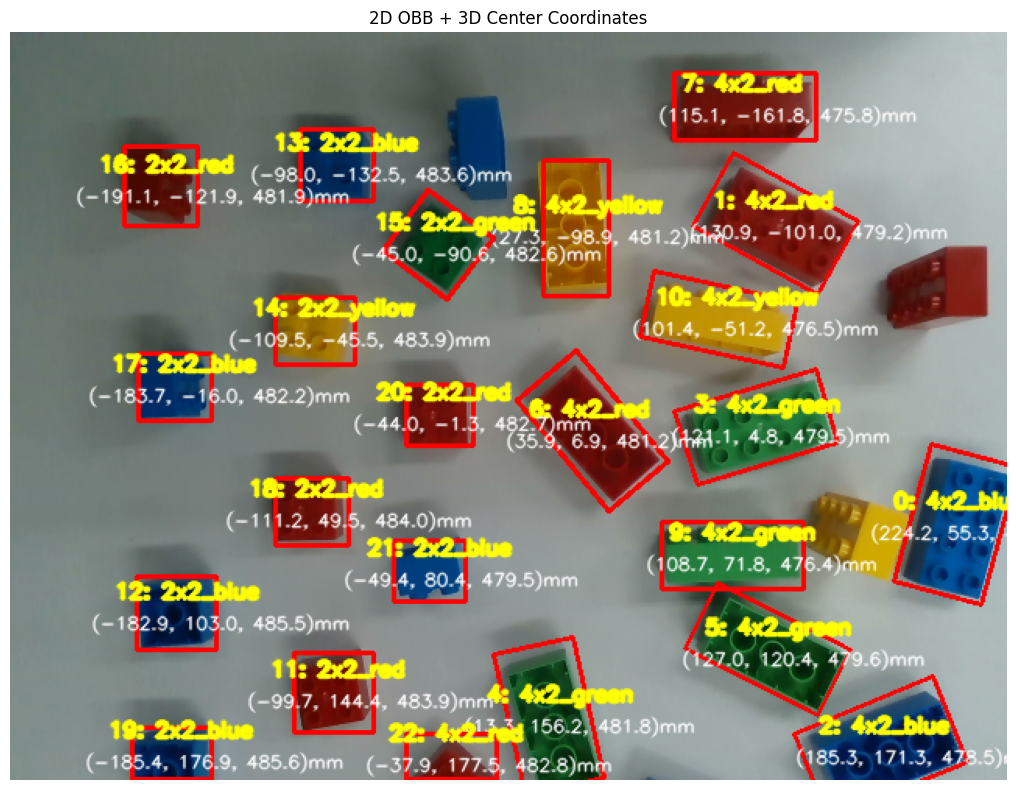


[INFO] 매끈한 바닥 + 객체 point cloud + 3D OBB 표시

[INFO] RGB-D 원본 point cloud 위에 3D OBB overlay 표시


In [42]:
# =================================================================
# [STEP 4] Convex Hull + side2 제외 마스크 기준으로 바닥/PCD 재생성
# =================================================================

pcd_data, plane_data, floor_pcd = build_floor_scene_data_from_depth(
    depth_img=depth,
    intrinsics=intrinsics,
    depth_scale=scale,
    object_mask_01=mask_no_side2,
    depth_trunc=5.0,
    voxel_size=0.003,
    plane_dist_thresh=0.015,
    floor_height_eps=0.005,
    visualize=False
)


# =================================================================
# [STEP 5] Convex Hull 객체 기준 3D OBB 생성
# =================================================================

objects_obb, vis_3d, overlay_3d, vis_2d_rgb, obb_results = generate_3d_obbs_from_hull_objects(
    objects=objects_no_side2,
    refined_mask_01=mask_no_side2,
    pcd_data=pcd_data,
    plane_data=plane_data,
    intrinsics=intrinsics,
    color_img_rgb=color_rgb,
    floor_pcd=floor_pcd,
    min_height=0.024,
    max_height_limit=0.12,
    height_percentile=95,
    visualize_2d=True
)

# =================================================================
# [STEP 6] Open3D 분석용 시각화
# =================================================================

print("\n[INFO] 매끈한 바닥 + 객체 point cloud + 3D OBB 표시")
o3d.visualization.draw_geometries(
    vis_3d,
    window_name="Smooth Floor + Convex Hull Object 3D OBBs"
)

# =================================================================
# [STEP 7] RGB-D 원본 point cloud 위에 OBB overlay
# =================================================================

color_o3d = o3d.geometry.Image(color_rgb)
depth_o3d = o3d.geometry.Image(cv2.medianBlur(depth, 5))

o3d_intr = o3d.camera.PinholeCameraIntrinsic(
    int(intrinsics.width),
    int(intrinsics.height),
    float(intrinsics.fx),
    float(intrinsics.fy),
    float(intrinsics.ppx),
    float(intrinsics.ppy)
)

rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_o3d,
    depth_o3d,
    depth_scale=1.0 / float(scale),
    depth_trunc=5.0,
    convert_rgb_to_intensity=False
)

rgb_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image,
    o3d_intr
)

rgb_pcd = rgb_pcd.voxel_down_sample(voxel_size=0.0015)

final_overlay_elements = [rgb_pcd] + overlay_3d

print("\n[INFO] RGB-D 원본 point cloud 위에 3D OBB overlay 표시")
o3d.visualization.draw_geometries(
    final_overlay_elements,
    window_name="RGB-D Point Cloud + Convex Hull 3D OBBs"
)

In [43]:
import numpy as np
import open3d as o3d

try:
    from scipy.spatial.transform import Rotation as R
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False


def normalize_vec(v, eps=1e-9):
    v = np.asarray(v, dtype=np.float64)
    n = np.linalg.norm(v)
    if n < eps:
        return None
    return v / n


def rotation_matrix_to_rpy_xyz_deg(R_mat):
    """
    Camera frame 기준 roll, pitch, yaw 계산.
    Convention:
        R_mat columns = [object_x, object_y, object_z] in camera coordinates
        Euler order = xyz
    """
    if SCIPY_AVAILABLE:
        rpy = R.from_matrix(R_mat).as_euler("xyz", degrees=True)
        return rpy  # roll, pitch, yaw

    # scipy 없을 때 fallback
    sy = np.sqrt(R_mat[0, 0] ** 2 + R_mat[1, 0] ** 2)

    singular = sy < 1e-6

    if not singular:
        roll = np.arctan2(R_mat[2, 1], R_mat[2, 2])
        pitch = np.arctan2(-R_mat[2, 0], sy)
        yaw = np.arctan2(R_mat[1, 0], R_mat[0, 0])
    else:
        roll = np.arctan2(-R_mat[1, 2], R_mat[1, 1])
        pitch = np.arctan2(-R_mat[2, 0], sy)
        yaw = 0.0

    return np.rad2deg([roll, pitch, yaw])


def make_axes_lineset(center, R_obj_cam, axis_size=0.04):
    """
    Open3D 좌표축 LineSet 생성.
    X: red
    Y: green
    Z: blue
    """
    center = np.asarray(center, dtype=np.float64)

    x_axis = R_obj_cam[:, 0]
    y_axis = R_obj_cam[:, 1]
    z_axis = R_obj_cam[:, 2]

    points = np.array([
        center,
        center + x_axis * axis_size,
        center,
        center + y_axis * axis_size,
        center,
        center + z_axis * axis_size,
    ], dtype=np.float64)

    lines = [
        [0, 1],
        [2, 3],
        [4, 5],
    ]

    colors = [
        [1.0, 0.0, 0.0],  # X red
        [0.0, 1.0, 0.0],  # Y green
        [0.0, 0.2, 1.0],  # Z blue
    ]

    axes = o3d.geometry.LineSet()
    axes.points = o3d.utility.Vector3dVector(points)
    axes.lines = o3d.utility.Vector2iVector(lines)
    axes.colors = o3d.utility.Vector3dVector(colors)

    return axes


def estimate_pose_axes_from_obb3d(
    obb_3d,
    plane_normal,
    class_name="unknown",
    axis_size=0.04
):
    """
    3D OBB corners를 기준으로 object coordinate frame 계산.

    Args:
        obb_3d:
            obj["obb_3d"] 딕셔너리
        plane_normal:
            plane_data["normal"]
        class_name:
            객체 이름
        axis_size:
            Open3D 좌표축 길이

    Returns:
        pose_data dict
    """

    if obb_3d is None:
        return None

    corners = np.asarray(obb_3d["corners_3d_m"], dtype=np.float64)
    center = np.asarray(obb_3d["center_3d_m"], dtype=np.float64)

    if corners.shape[0] < 8:
        return None

    # 바닥 4점
    floor_corners = corners[:4]

    # Z축: 바닥 normal
    z_axis = normalize_vec(plane_normal)
    if z_axis is None:
        return None

    # 바닥 사각형의 4개 edge 계산
    edge_candidates = []

    for i in range(4):
        p0 = floor_corners[i]
        p1 = floor_corners[(i + 1) % 4]
        e = p1 - p0

        # normal 성분 제거해서 바닥 평면 위 방향으로 보정
        e = e - np.dot(e, z_axis) * z_axis

        length = np.linalg.norm(e)
        if length > 1e-6:
            edge_candidates.append((length, e, i))

    if len(edge_candidates) == 0:
        return None

    # X축: 가장 긴 edge 방향
    edge_candidates.sort(key=lambda x: x[0], reverse=True)
    x_axis = normalize_vec(edge_candidates[0][1])

    if x_axis is None:
        return None

    # X축 방향 부호 안정화
    # 카메라 좌표계에서 x 성분이 양수가 되게 함.
    # 필요 없으면 이 블록 삭제 가능.
    if x_axis[0] < 0:
        x_axis = -x_axis

    # Y축: 오른손 좌표계
    y_axis = np.cross(z_axis, x_axis)
    y_axis = normalize_vec(y_axis)

    if y_axis is None:
        return None

    # X축 재직교화
    x_axis = np.cross(y_axis, z_axis)
    x_axis = normalize_vec(x_axis)

    # Rotation matrix
    # columns = object axes in camera frame
    R_obj_cam = np.column_stack([x_axis, y_axis, z_axis])

    # det 보정
    if np.linalg.det(R_obj_cam) < 0:
        y_axis = -y_axis
        R_obj_cam = np.column_stack([x_axis, y_axis, z_axis])

    rpy_deg = rotation_matrix_to_rpy_xyz_deg(R_obj_cam)

    axes_3d = make_axes_lineset(
        center=center,
        R_obj_cam=R_obj_cam,
        axis_size=axis_size
    )

    pose_data = {
        "class_name": class_name,
        "center_m": center,
        "center_mm": center * 1000.0,
        "R_obj_cam": R_obj_cam,
        "x_axis": x_axis,
        "y_axis": y_axis,
        "z_axis": z_axis,
        "roll_deg": float(rpy_deg[0]),
        "pitch_deg": float(rpy_deg[1]),
        "yaw_deg": float(rpy_deg[2]),
        "axes_3d": axes_3d,
    }

    return pose_data

In [47]:
# =================================================================
# [STEP] 3D OBB 기준 객체 좌표계 + Camera 기준 RPY 계산
# =================================================================

pose_results = []
axes_geometries = []

plane_normal = plane_data["normal"]

for idx, obj in enumerate(objects_obb):
    obb_3d = obj.get("obb_3d", None)
    class_name = obj.get("class_name", "unknown")

    pose = estimate_pose_axes_from_obb3d(
        obb_3d=obb_3d,
        plane_normal=plane_normal,
        class_name=class_name,
        axis_size=0.04
    )

    if pose is None:
        print(f"[SKIP] idx {idx}: pose 계산 실패")
        continue

    obj["pose_cam"] = pose
    pose_results.append({
        "idx": idx,
        "class_name": class_name,
        "center_mm": pose["center_mm"],
        "roll_deg": pose["roll_deg"],
        "pitch_deg": pose["pitch_deg"],
        "yaw_deg": pose["yaw_deg"],
        "R_obj_cam": pose["R_obj_cam"],
    })

    axes_geometries.append(pose["axes_3d"])

    c = pose["center_mm"]

    print(
        f"idx {idx:02d} | {class_name:20s} | "
        f"center(mm)=({c[0]:7.1f}, {c[1]:7.1f}, {c[2]:7.1f}) | "
        f"RPY(deg)=({pose['roll_deg']:7.2f}, "
        f"{pose['pitch_deg']:7.2f}, "
        f"{pose['yaw_deg']:7.2f})"
    )

    # 기존 3D OBB geometry에 좌표축 추가
vis_3d_with_axes = vis_3d + axes_geometries
overlay_3d_with_axes = overlay_3d + axes_geometries

print("\n[INFO] 3D OBB + Object Coordinate Axes 표시")
o3d.visualization.draw_geometries(
    vis_3d_with_axes,
    window_name="3D OBB + Object XYZ Axes"
)

color_o3d = o3d.geometry.Image(color_rgb)
depth_o3d = o3d.geometry.Image(cv2.medianBlur(depth, 5))

o3d_intr = o3d.camera.PinholeCameraIntrinsic(
    int(intrinsics.width),
    int(intrinsics.height),
    float(intrinsics.fx),
    float(intrinsics.fy),
    float(intrinsics.ppx),
    float(intrinsics.ppy)
)

rgbd_image = o3d.geometry.RGBDImage.create_from_color_and_depth(
    color_o3d,
    depth_o3d,
    depth_scale=1.0 / float(scale),
    depth_trunc=5.0,
    convert_rgb_to_intensity=False
)

rgb_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(
    rgbd_image,
    o3d_intr
)

rgb_pcd = rgb_pcd.voxel_down_sample(voxel_size=0.0015)

final_overlay_elements = [rgb_pcd] + overlay_3d_with_axes

print("\n[INFO] RGB-D PointCloud + 3D OBB + Object Axes 표시")
o3d.visualization.draw_geometries(
    final_overlay_elements,
    window_name="RGB-D PointCloud + Object XYZ Axes"
)

idx 00 | 4x2_blue             | center(mm)=(  224.2,    55.3,   477.6) | RPY(deg)=( 178.96,    0.35,  -74.90)
idx 01 | 4x2_red              | center(mm)=(  130.9,  -101.0,   479.2) | RPY(deg)=(-179.41,    0.92,   29.06)
idx 02 | 4x2_blue             | center(mm)=(  185.3,   171.3,   478.5) | RPY(deg)=( 179.64,    1.03,  -23.01)
idx 03 | 4x2_green            | center(mm)=(  121.1,     4.8,   479.5) | RPY(deg)=( 179.75,    1.07,  -16.57)
idx 04 | 4x2_green            | center(mm)=(   13.3,   156.2,   481.8) | RPY(deg)=(-178.92,    0.18,   76.99)
idx 05 | 4x2_green            | center(mm)=(  127.0,   120.4,   479.6) | RPY(deg)=(-179.45,    0.95,   26.71)
idx 06 | 4x2_red              | center(mm)=(   35.9,     6.9,   481.2) | RPY(deg)=(-179.12,    0.65,   50.28)
idx 07 | 4x2_red              | center(mm)=(  115.1,  -161.8,   475.8) | RPY(deg)=(-179.93,    1.09,    0.32)
idx 08 | 4x2_yellow           | center(mm)=(   27.3,   -98.9,   481.2) | RPY(deg)=(-178.91,   -0.07,   90.00)
idx 09 | 4

In [49]:
import numpy as np
import pandas as pd
import re


def normalize_class_name(name, remove_c_prefix=True, remove_side2=False):
    """
    '[C]2x2_red_side2' 같은 이름을 정리.
    """
    name = str(name)

    if remove_c_prefix:
        name = name.replace("[C]", "")

    if remove_side2:
        name = name.replace("_side2", "")

    return name


def build_class_sorted_pose_index(
    objects_obb,
    use_pose_cam=True,
    remove_c_prefix=True,
    remove_side2=False,
    verbose=True
):
    """
    객체들을 클래스별로 묶고, 카메라 optical axis에서 가까운 순서대로 local_id 부여.

    기준:
        axis_dist_m = sqrt(x^2 + y^2)

    Args:
        objects_obb:
            obj["obb_3d"] 또는 obj["pose_cam"]이 들어있는 객체 리스트

        use_pose_cam:
            True면 obj["pose_cam"]["center_m"] 우선 사용
            False면 obj["obb_3d"]["center_3d_m"] 사용

    Returns:
        pose_table:
            list[dict], 모든 객체 pose 정보

        class_index:
            dict[class_name] = 해당 클래스 객체 리스트, axis_dist_m 오름차순
    """

    pose_table = []

    for global_idx, obj in enumerate(objects_obb):
        raw_name = obj.get("class_name", "unknown")
        class_name = normalize_class_name(
            raw_name,
            remove_c_prefix=remove_c_prefix,
            remove_side2=remove_side2
        )

        center_m = None
        roll_deg = None
        pitch_deg = None
        yaw_deg = None
        R_obj_cam = None

        # 1순위: pose_cam
        if use_pose_cam and obj.get("pose_cam", None) is not None:
            pose = obj["pose_cam"]
            center_m = np.asarray(pose["center_m"], dtype=np.float64)
            roll_deg = float(pose["roll_deg"])
            pitch_deg = float(pose["pitch_deg"])
            yaw_deg = float(pose["yaw_deg"])
            R_obj_cam = pose["R_obj_cam"]

        # 2순위: obb_3d
        elif obj.get("obb_3d", None) is not None:
            obb = obj["obb_3d"]
            center_m = np.asarray(obb["center_3d_m"], dtype=np.float64)

            # 아직 RPY가 없으면 None
            roll_deg = None
            pitch_deg = None
            yaw_deg = None
            R_obj_cam = None

        else:
            if verbose:
                print(f"[SKIP] global_idx {global_idx}: pose/obb 없음")
            continue

        x, y, z = center_m
        axis_dist_m = float(np.sqrt(x**2 + y**2))
        depth_m = float(z)

        item = {
            "global_idx": global_idx,
            "class_name": class_name,
            "raw_class_name": raw_name,
            "axis_dist_m": axis_dist_m,
            "axis_dist_mm": axis_dist_m * 1000.0,
            "depth_m": depth_m,
            "x_m": float(x),
            "y_m": float(y),
            "z_m": float(z),
            "x_mm": float(x * 1000.0),
            "y_mm": float(y * 1000.0),
            "z_mm": float(z * 1000.0),
            "roll_deg": roll_deg,
            "pitch_deg": pitch_deg,
            "yaw_deg": yaw_deg,
            "R_obj_cam": R_obj_cam,
            "object_ref": obj,
        }

        pose_table.append(item)

    # 전체를 optical axis 거리 기준으로 정렬
    pose_table = sorted(pose_table, key=lambda x: x["axis_dist_m"])

    # 클래스별 묶기
    class_index = {}

    for item in pose_table:
        cls = item["class_name"]

        if cls not in class_index:
            class_index[cls] = []

        class_index[cls].append(item)

    # 클래스 내부 local_id 부여
    for cls, items in class_index.items():
        items.sort(key=lambda x: x["axis_dist_m"])

        for local_id, item in enumerate(items):
            item["local_id"] = local_id

    if verbose:
        print("\n[클래스별 optical axis 가까운 순서]")
        for cls, items in class_index.items():
            print(f"\nClass: {cls}")

            for item in items:
                print(
                    f"  local_id {item['local_id']:02d} | "
                    f"global_idx {item['global_idx']:02d} | "
                    f"axis_dist={item['axis_dist_mm']:.1f} mm | "
                    f"center=({item['x_mm']:.1f}, {item['y_mm']:.1f}, {item['z_mm']:.1f}) mm | "
                    f"RPY=({item['roll_deg']}, {item['pitch_deg']}, {item['yaw_deg']})"
                )

    return pose_table, class_index

In [50]:
pose_table, class_index = build_class_sorted_pose_index(
    objects_obb=objects_obb,
    use_pose_cam=True,
    remove_c_prefix=True,
    remove_side2=False,
    verbose=True
)


[클래스별 optical axis 가까운 순서]

Class: 4x2_red
  local_id 00 | global_idx 06 | axis_dist=36.5 mm | center=(35.9, 6.9, 481.2) mm | RPY=(-179.1165432469748, 0.645593653865456, 50.283105206727306)
  local_id 01 | global_idx 01 | axis_dist=165.3 mm | center=(130.9, -101.0, 479.2) mm | RPY=(-179.41017340619476, 0.921622787874991, 29.05890934523726)
  local_id 02 | global_idx 22 | axis_dist=181.5 mm | center=(-37.9, 177.5, 482.8) mm | RPY=(-179.93999758334817, 1.0925447885007933, -0.4181356658493301)
  local_id 03 | global_idx 07 | axis_dist=198.6 mm | center=(115.1, -161.8, 475.8) mm | RPY=(-179.92591377822518, 1.091680294073829, 0.32078110944405913)

Class: 2x2_red
  local_id 00 | global_idx 20 | axis_dist=44.0 mm | center=(-44.0, -1.3, 482.7) mm | RPY=(-179.93264234460915, 1.092116048895002, -0.03231094856561036)
  local_id 01 | global_idx 18 | axis_dist=121.7 mm | center=(-111.2, 49.5, 484.0) mm | RPY=(-179.93484112737698, 1.0922494239638254, -0.1476657841575071)
  local_id 02 | global_idx 

In [51]:
def get_nearest_6d_pose_by_class(
    class_index,
    target_class_name,
    local_id=0,
    remove_c_prefix=True,
    remove_side2=False
):
    """
    클래스 이름으로 요청하면 optical axis 기준 가까운 순서 중 local_id번째 객체의 6D 반환.

    예:
        get_nearest_6d_pose_by_class(class_index, "2x2_red", local_id=0)
    """

    target = normalize_class_name(
        target_class_name,
        remove_c_prefix=remove_c_prefix,
        remove_side2=remove_side2
    )

    if target not in class_index:
        print(f"❌ 요청 클래스 없음: {target}")
        print("가능 클래스:", list(class_index.keys()))
        return None

    items = class_index[target]

    if local_id >= len(items):
        print(f"❌ {target} 클래스에 local_id {local_id} 없음. 개수: {len(items)}")
        return None

    item = items[local_id]

    result_6d = {
        "class_name": item["class_name"],
        "local_id": item["local_id"],
        "global_idx": item["global_idx"],

        # position
        "x_m": item["x_m"],
        "y_m": item["y_m"],
        "z_m": item["z_m"],

        "x_mm": item["x_mm"],
        "y_mm": item["y_mm"],
        "z_mm": item["z_mm"],

        # orientation
        "roll_deg": item["roll_deg"],
        "pitch_deg": item["pitch_deg"],
        "yaw_deg": item["yaw_deg"],

        # sorting metric
        "axis_dist_m": item["axis_dist_m"],
        "axis_dist_mm": item["axis_dist_mm"],

        # matrix
        "R_obj_cam": item["R_obj_cam"],
    }

    print("\n[요청 객체 6D Pose]")
    print(f"Class      : {result_6d['class_name']}")
    print(f"local_id   : {result_6d['local_id']}")
    print(f"global_idx : {result_6d['global_idx']}")
    print(
        f"Position mm: "
        f"x={result_6d['x_mm']:.1f}, "
        f"y={result_6d['y_mm']:.1f}, "
        f"z={result_6d['z_mm']:.1f}"
    )
    print(
        f"RPY deg    : "
        f"roll={result_6d['roll_deg']:.2f}, "
        f"pitch={result_6d['pitch_deg']:.2f}, "
        f"yaw={result_6d['yaw_deg']:.2f}"
    )
    print(f"Axis dist  : {result_6d['axis_dist_mm']:.1f} mm")

    return result_6d

In [52]:
pose_2x2_red_0 = get_nearest_6d_pose_by_class(
    class_index=class_index,
    target_class_name="2x2_red",
    local_id=0
)


[요청 객체 6D Pose]
Class      : 2x2_red
local_id   : 0
global_idx : 20
Position mm: x=-44.0, y=-1.3, z=482.7
RPY deg    : roll=-179.93, pitch=1.09, yaw=-0.03
Axis dist  : 44.0 mm


In [53]:
rows = []

for item in pose_table:
    rows.append({
        "class_name": item["class_name"],
        "local_id": item.get("local_id", None),
        "global_idx": item["global_idx"],
        "axis_dist_mm": item["axis_dist_mm"],
        "x_mm": item["x_mm"],
        "y_mm": item["y_mm"],
        "z_mm": item["z_mm"],
        "roll_deg": item["roll_deg"],
        "pitch_deg": item["pitch_deg"],
        "yaw_deg": item["yaw_deg"],
    })

pose_df = pd.DataFrame(rows)
pose_df = pose_df.sort_values(["class_name", "local_id"])
display(pose_df)

,class_name,local_id,global_idx,axis_dist_mm,x_mm,y_mm,z_mm,roll_deg,pitch_deg,yaw_deg
2,2x2_blue,0,21,94.335793,-49.367304,80.387258,479.457543,-179.936078,1.092323,-0.212565
11,2x2_blue,1,13,164.807706,-98.009713,-132.497834,483.552424,-179.927252,1.091770,0.250546
16,2x2_blue,2,17,184.439851,-183.741062,-16.039971,482.166365,-179.932093,1.092082,-0.003477
18,2x2_blue,3,12,209.897644,-182.909482,102.961850,485.450231,-179.937144,1.092384,-0.268458
22,2x2_blue,4,19,256.255554,-185.421780,176.877563,485.585829,-179.939998,1.092545,-0.418136
3,2x2_green,0,15,101.178321,-44.993425,-90.623641,482.591480,-179.295088,0.836892,36.547928
1,2x2_red,0,20,43.994754,-43.976501,-1.267164,482.678123,-179.932642,1.092116,-0.032311
8,2x2_red,1,18,121.701942,-111.193903,49.469978,484.019669,-179.934841,1.092249,-0.147666
14,2x2_red,2,11,175.464042,-99.719659,144.373195,483.913549,-179.938966,1.092488,-0.364030
19,2x2_red,3,16,226.695425,-191.135468,-121.893597,481.921979,178.907957,0.068538,-89.971045


### 상하 측면을 보는건데, 이 밑으로는 HSV 칼라 영역 전처리 - 누끼를 더 예쁘게 따는 법이 있을지

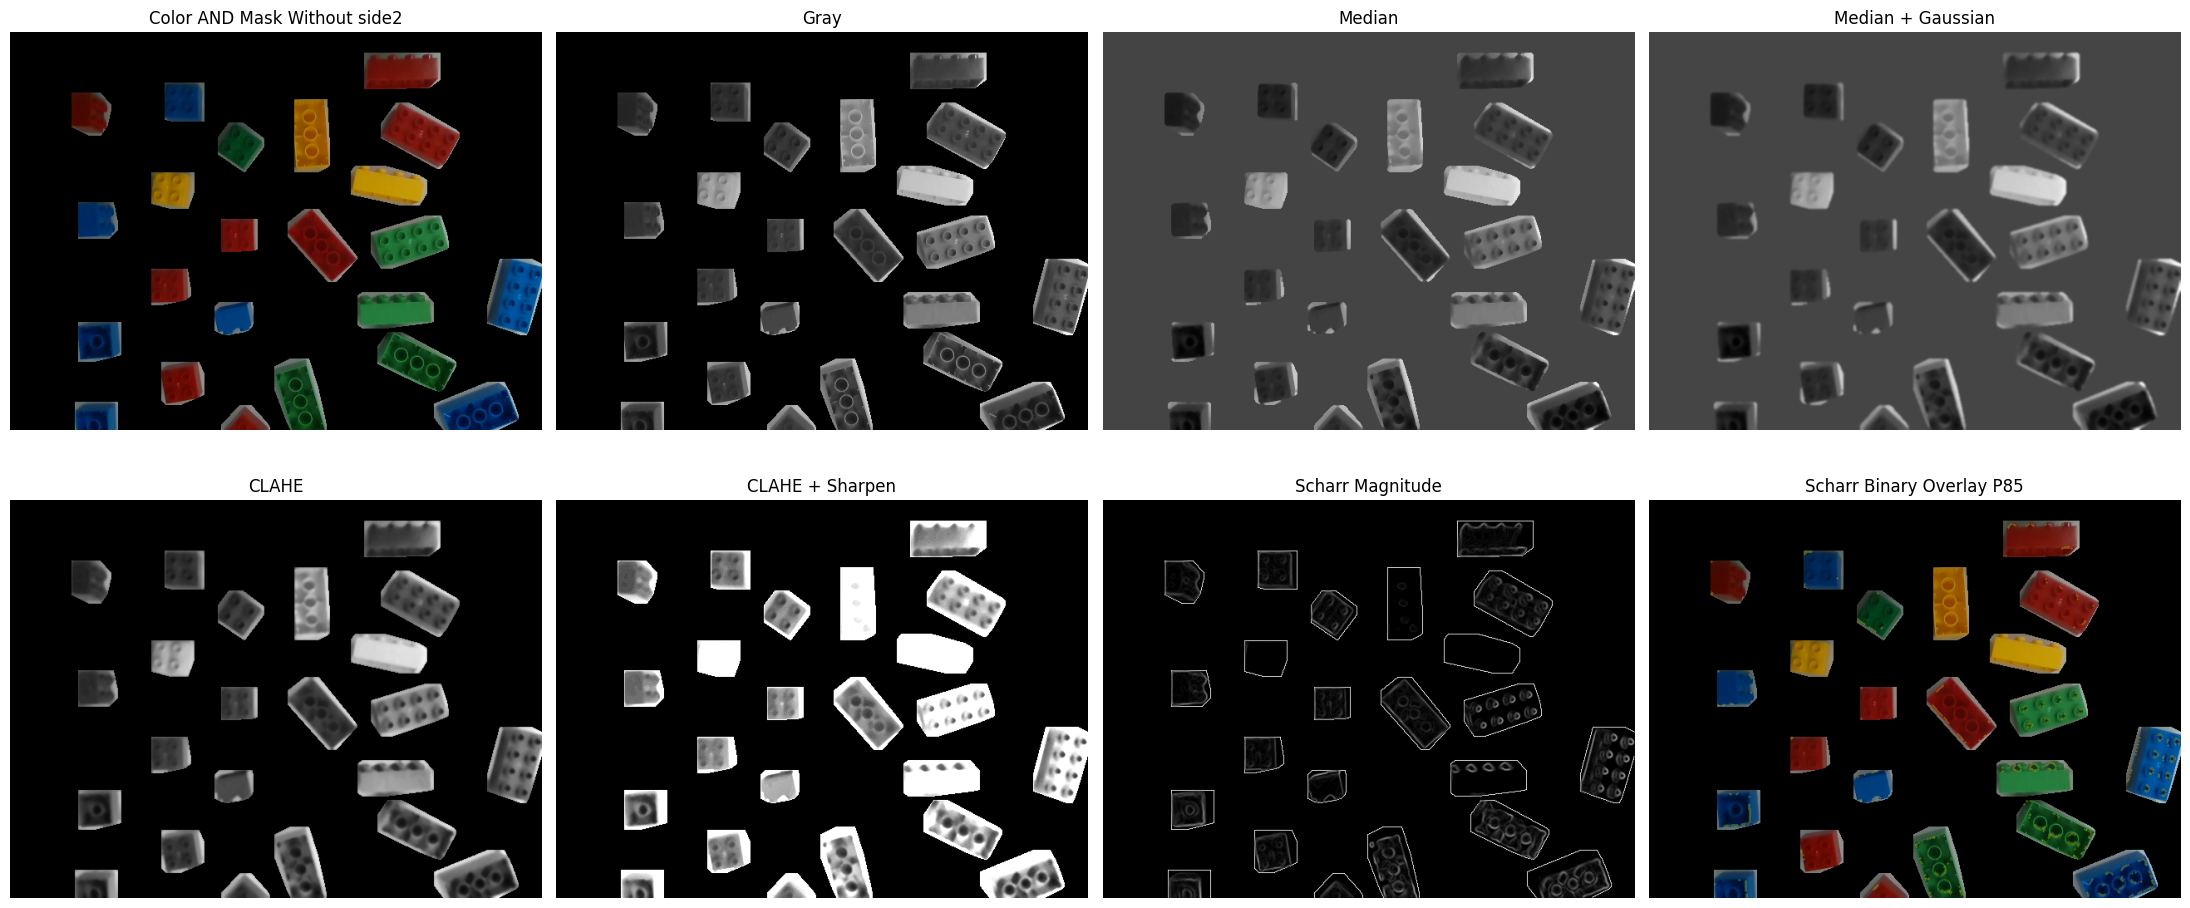

In [32]:
# =================================================================
# Median → Gaussian → CLAHE → Sharpen → Scharr 만 보기
# 입력:
#   color_no_side2_bgr
#   mask_no_side2
# =================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Gray
# ------------------------------------------------------------
gray = cv2.cvtColor(color_no_side2_bgr, cv2.COLOR_BGR2GRAY)

# 마스크 바깥을 내부 median 값으로 채움
# 이유: 검정 배경 경계가 Scharr에서 강한 edge로 터지는 것 방지
valid_pixels = gray[mask_no_side2 > 0]

if len(valid_pixels) > 0:
    fill_value = int(np.median(valid_pixels))
else:
    fill_value = 0

gray_bg_filled = gray.copy()
gray_bg_filled[mask_no_side2 == 0] = fill_value

# ------------------------------------------------------------
# 2. Median
# ------------------------------------------------------------
median_ksize = 5
gray_median = cv2.medianBlur(gray_bg_filled, median_ksize)

# ------------------------------------------------------------
# 3. Gaussian
# ------------------------------------------------------------
gaussian_ksize = 5
gray_gaussian = cv2.GaussianBlur(
    gray_median,
    (gaussian_ksize, gaussian_ksize),
    sigmaX=0
)

# ------------------------------------------------------------
# 4. CLAHE
# ------------------------------------------------------------
clahe = cv2.createCLAHE(
    clipLimit=2,
    tileGridSize=(8, 8)
)
gray_clahe = clahe.apply(gray_gaussian)

# 마스크 바깥 제거
mask_no_side2_255 = (mask_no_side2.astype(np.uint8) * 255)

gray_clahe_masked = cv2.bitwise_and(
    gray_clahe,
    gray_clahe,
    mask=mask_no_side2_255
)

# ------------------------------------------------------------
# 5. Sharpening
# ------------------------------------------------------------
sharpen_kernel = np.array([
    [0, -1,  0],
    [-1, 7, -1],
    [0, -1,  0]
], dtype=np.float32)

gray_sharp = cv2.filter2D(gray_clahe_masked, -1, sharpen_kernel)

# ------------------------------------------------------------
# 6. Scharr Gradient
# ------------------------------------------------------------
scharr_x = cv2.Scharr(gray_sharp, cv2.CV_32F, 1, 0)
scharr_y = cv2.Scharr(gray_sharp, cv2.CV_32F, 0, 1)

scharr_mag = cv2.magnitude(scharr_x, scharr_y)

scharr_mag_u8 = cv2.normalize(
    scharr_mag,
    None,
    0,
    255,
    cv2.NORM_MINMAX
).astype(np.uint8)

scharr_mag_u8 = cv2.bitwise_and(
    scharr_mag_u8,
    scharr_mag_u8,
    mask=mask_no_side2_255
)

# ------------------------------------------------------------
# 7. Scharr Binary
# ------------------------------------------------------------
scharr_percentile = 85

valid_scharr = scharr_mag_u8[mask_no_side2 > 0]

if len(valid_scharr) > 0:
    scharr_th = np.percentile(valid_scharr, scharr_percentile)
else:
    scharr_th = 0

scharr_bin = ((scharr_mag_u8 >= scharr_th) & (mask_no_side2 > 0)).astype(np.uint8) * 255

# 노이즈 정리
kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
scharr_bin_clean = cv2.morphologyEx(scharr_bin, cv2.MORPH_OPEN, kernel_small)
scharr_bin_clean = cv2.morphologyEx(scharr_bin_clean, cv2.MORPH_CLOSE, kernel_small)

# ------------------------------------------------------------
# 8. Overlay
# ------------------------------------------------------------
scharr_overlay = color_no_side2_bgr.copy()
scharr_overlay[scharr_bin_clean > 0] = (0, 255, 255)

scharr_overlay = cv2.addWeighted(
    color_no_side2_bgr,
    0.75,
    scharr_overlay,
    0.25,
    0
)

# ------------------------------------------------------------
# 9. 시각화
# ------------------------------------------------------------
plt.figure(figsize=(22, 10))

plt.subplot(2, 4, 1)
plt.imshow(cv2.cvtColor(color_no_side2_bgr, cv2.COLOR_BGR2RGB))
plt.title("Color AND Mask Without side2")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(gray, cmap="gray")
plt.title("Gray")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(gray_median, cmap="gray")
plt.title("Median")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(gray_gaussian, cmap="gray")
plt.title("Median + Gaussian")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(gray_clahe_masked, cmap="gray")
plt.title("CLAHE")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(gray_sharp, cmap="gray")
plt.title("CLAHE + Sharpen")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(scharr_mag_u8, cmap="gray")
plt.title("Scharr Magnitude")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.imshow(cv2.cvtColor(scharr_overlay, cv2.COLOR_BGR2RGB))
plt.title(f"Scharr Binary Overlay P{scharr_percentile}")
plt.axis("off")

plt.tight_layout()
plt.show()

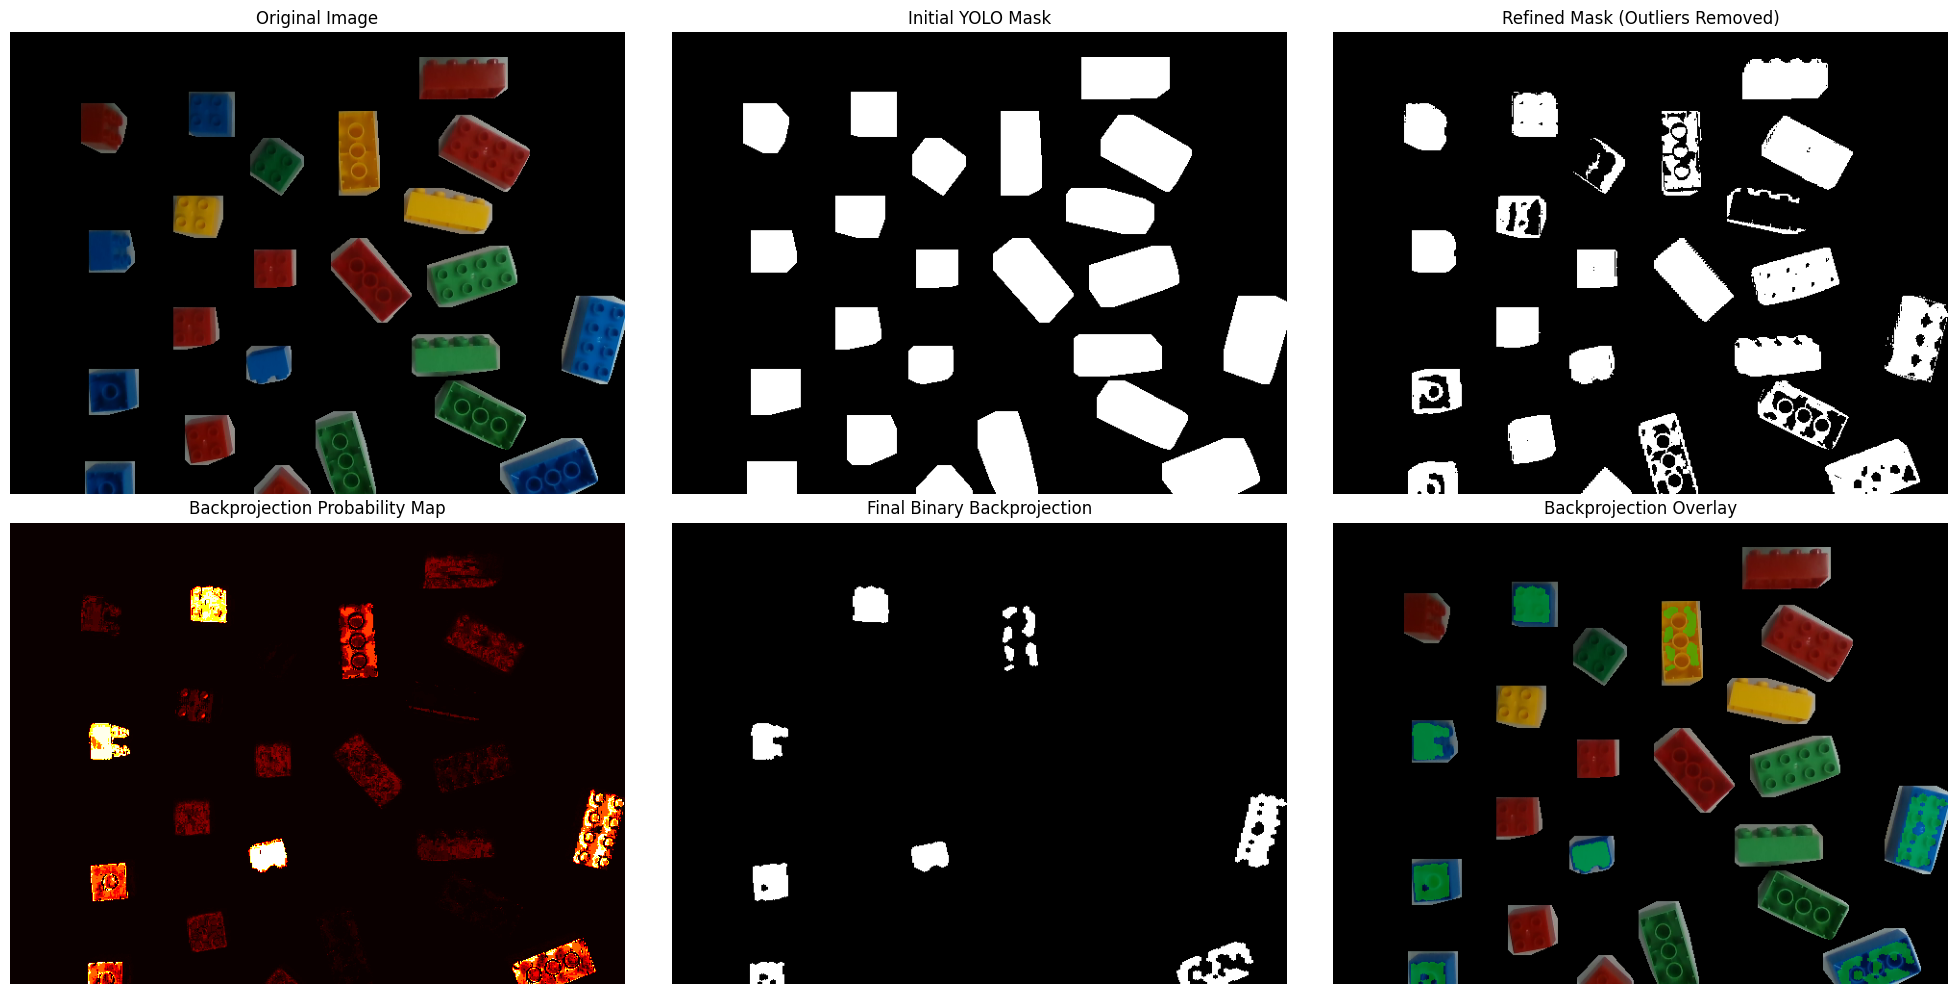

In [33]:
# =================================================================
# YOLO Mask 내부 Outlier 제거 → 2D 히스토그램 추출 → 역투영(Backprojection)
# 입력:
#   color_no_side2_bgr (원본 BGR 이미지)
#   mask_no_side2 (YOLO 등에서 얻은 초기 마스크, 0 또는 255/1 로 구성)
# =================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. HSV 변환 및 채널 분리
# ------------------------------------------------------------
hsv = cv2.cvtColor(color_no_side2_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

# ------------------------------------------------------------
# 2. Outlier(값이 확 튀는 픽셀) 제거를 위한 정제 마스크 생성
# ------------------------------------------------------------
# YOLO 마스크가 유효한 영역의 S(채도)와 V(명도) 값만 추출
valid_s = s[mask_no_side2 > 0]
valid_v = v[mask_no_side2 > 0]

if len(valid_s) > 0 and len(valid_v) > 0:
    # 통계적 아웃라이어 제거 (Percentile 사용)
    # - V(명도): 조명 정반사(너무 밝음)와 짙은 그림자(너무 어두움) 제거 (상/하위 10% 컷)
    # - S(채도): 색을 잃어버린 무채색 노이즈 제거 (하위 10% 컷)
    s_min, s_max = np.percentile(valid_s, [10, 100])
    v_min, v_max = np.percentile(valid_v, [10, 90])
else:
    s_min, s_max, v_min, v_max = 0, 255, 0, 255

# 아웃라이어가 제거된 조건 생성
# (H는 색상 본연의 값이므로 임계값을 두지 않고, S와 V 조건만으로 픽셀을 거름)
outlier_filtered = cv2.inRange(
    hsv, 
    np.array([0, s_min, v_min]), 
    np.array([180, s_max, v_max])
)

# 최종 정제 마스크: YOLO 마스크 내부이면서 + 아웃라이어가 아닌 픽셀만 255
refined_mask = cv2.bitwise_and(mask_no_side2.astype(np.uint8) * 255, outlier_filtered)

# ------------------------------------------------------------
# 3. 2D 히스토그램 모델 추출 (H-S 채널)
# ------------------------------------------------------------
# 정제된 마스크(refined_mask) 영역에서만 타겟 객체의 H, S 분포를 학습
# V(명도)는 조명에 취약하므로 제외하고 2D(H, S) 히스토그램만 사용
hist_bins = [180, 256]
hist_ranges = [0, 180, 0, 256]

obj_hist = cv2.calcHist(
    [hsv], [0, 1], refined_mask, hist_bins, hist_ranges
)
# 역투영을 위해 히스토그램을 0~255 범위로 정규화
cv2.normalize(obj_hist, obj_hist, 0, 255, cv2.NORM_MINMAX)

# ------------------------------------------------------------
# 4. 역투영 (Backprojection) 적용
# ------------------------------------------------------------
# 계산된 히스토그램 모델을 전체 이미지(또는 관심 영역)에 투영하여 확률맵 생성
backproj_prob = cv2.calcBackProject(
    [hsv], [0, 1], obj_hist, hist_ranges, scale=1
)

# 배경 노이즈가 잡히는 것을 방지하기 위해 YOLO 마스크 영역 근처로 한정
# (필요에 따라 YOLO 마스크를 약간 팽창시켜서 사용할 수도 있음)
kernel_dilate = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (15, 15))
mask_dilated = cv2.dilate(mask_no_side2.astype(np.uint8), kernel_dilate, iterations=1)

backproj_masked = cv2.bitwise_and(backproj_prob, backproj_prob, mask=mask_dilated)

# ------------------------------------------------------------
# 5. 역투영 이진화 및 모폴로지 정리
# ------------------------------------------------------------
# 확률맵에서 일정 확률(예: 50) 이상인 곳만 타겟으로 인정
_, backproj_bin = cv2.threshold(backproj_masked, 50, 255, cv2.THRESH_BINARY)

# 노이즈 정리 (Opening으로 잔물결 제거, Closing으로 구멍 메우기)
kernel_morph = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
backproj_clean = cv2.morphologyEx(backproj_bin, cv2.MORPH_OPEN, kernel_morph)
backproj_clean = cv2.morphologyEx(backproj_clean, cv2.MORPH_CLOSE, kernel_morph)

# ------------------------------------------------------------
# 6. Overlay (시각화용)
# ------------------------------------------------------------
overlay_img = color_no_side2_bgr.copy()
# 역투영으로 찾은 최종 영역을 형광 녹색으로 표시
overlay_img[backproj_clean > 0] = (0, 255, 0) 

final_overlay = cv2.addWeighted(color_no_side2_bgr, 0.6, overlay_img, 0.4, 0)

# ------------------------------------------------------------
# 7. 시각화
# ------------------------------------------------------------
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(color_no_side2_bgr, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(mask_no_side2, cmap="gray")
plt.title("Initial YOLO Mask")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(refined_mask, cmap="gray")
plt.title("Refined Mask (Outliers Removed)")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(backproj_prob, cmap="hot")
plt.title("Backprojection Probability Map")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(backproj_clean, cmap="gray")
plt.title("Final Binary Backprojection")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(final_overlay, cv2.COLOR_BGR2RGB))
plt.title("Backprojection Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

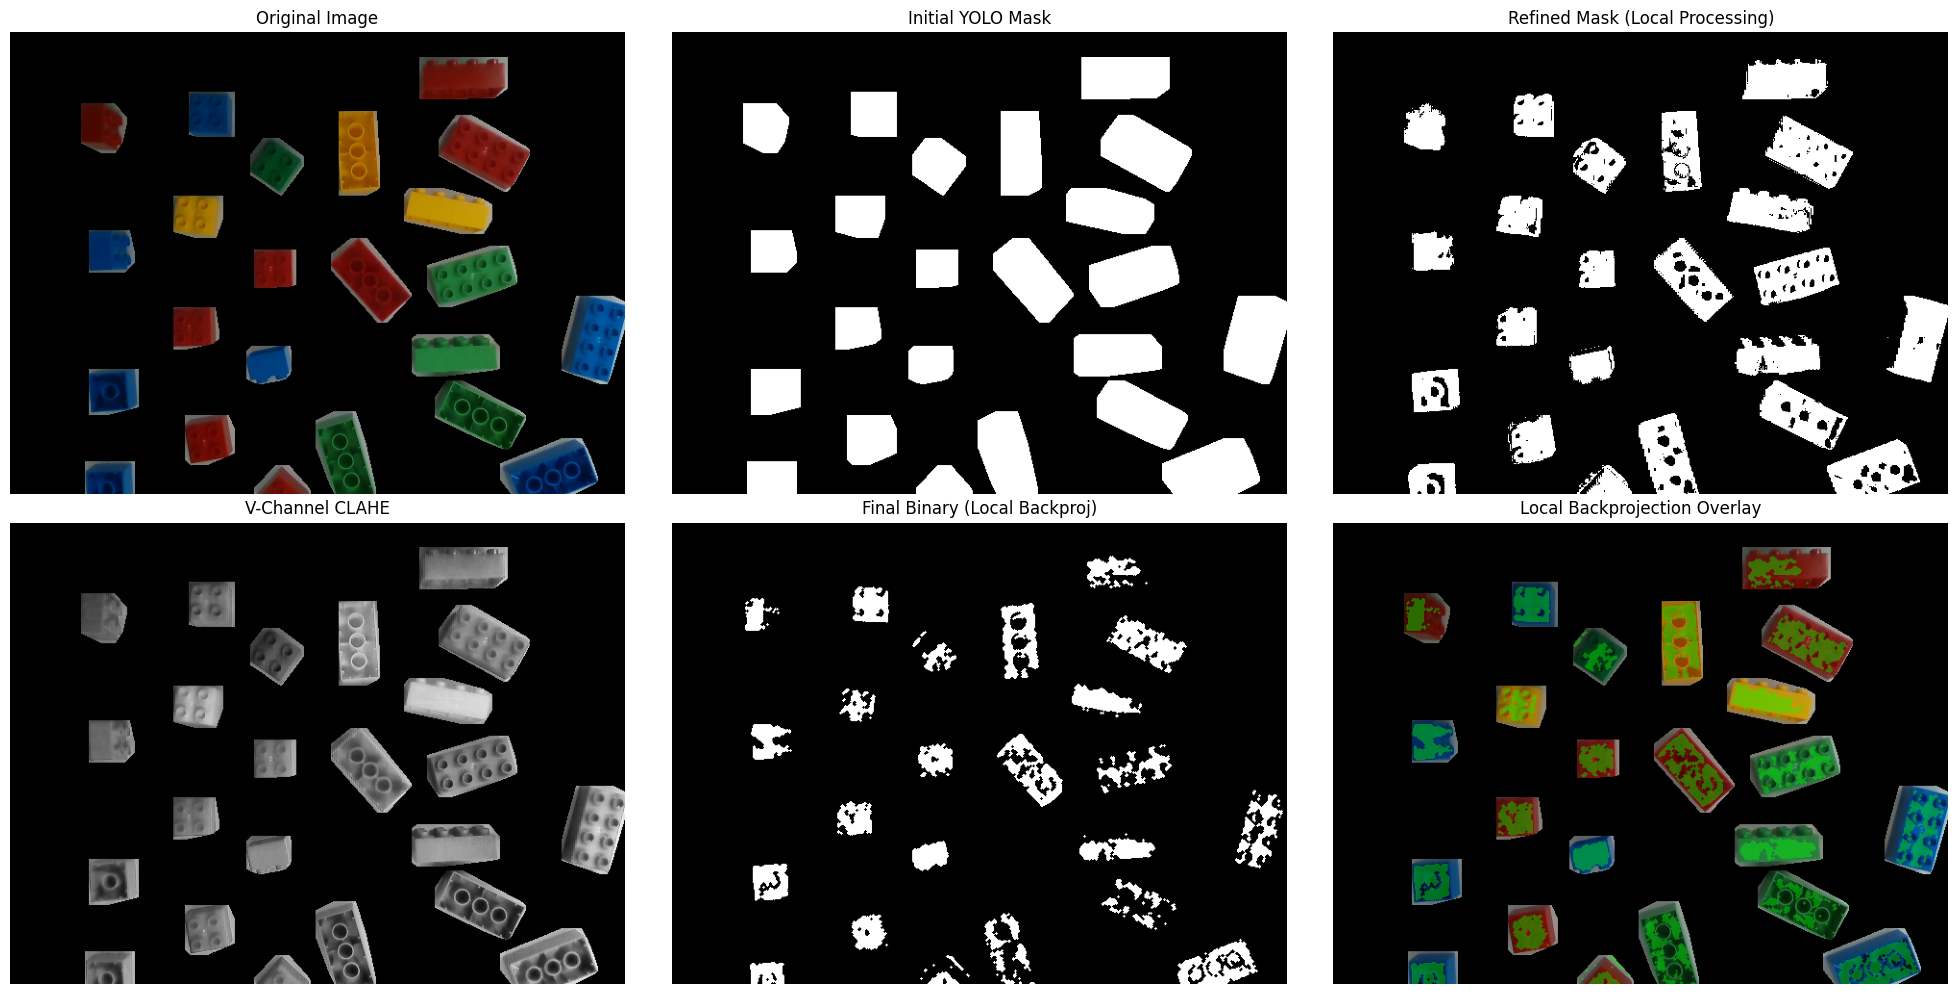

In [34]:
# =================================================================
# Local Mask 분리 + V채널 CLAHE 전처리 + 개별 객체 역투영
# 입력:
#   color_no_side2_bgr (원본 BGR 이미지)
#   mask_no_side2 (YOLO 초기 마스크, 0 또는 255)
# =================================================================

import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. HSV 변환 및 V채널 CLAHE 전처리
# ------------------------------------------------------------
# 색상(H)이 변질되는 것을 막기 위해 명도(V) 채널에만 CLAHE 적용
hsv = cv2.cvtColor(color_no_side2_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(hsv)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
v_clahe = clahe.apply(v)

# 전처리된 HSV 이미지 재조립
hsv_clahe = cv2.merge([h, s, v_clahe])

# ------------------------------------------------------------
# 2. YOLO 마스크 개별 분리 (Contours 찾기)
# ------------------------------------------------------------
# 마스크 내의 개별 객체(레고 블록)들을 분리
contours, _ = cv2.findContours(
    mask_no_side2.astype(np.uint8), 
    cv2.RETR_EXTERNAL, 
    cv2.CHAIN_APPROX_SIMPLE
)

# 최종 결과를 담을 빈 캔버스
final_backproj_bin = np.zeros_like(mask_no_side2, dtype=np.uint8)
refined_global_mask = np.zeros_like(mask_no_side2, dtype=np.uint8)

# ------------------------------------------------------------
# 3. 객체별(Local) 처리 루프
# ------------------------------------------------------------
for cnt in contours:
    # 너무 작은 노이즈 마스크 무시
    if cv2.contourArea(cnt) < 50:
        continue
        
    # 3-1. 개별 객체용 Local Mask 생성 (Convex Hull 적용 가능)
    hull = cv2.convexHull(cnt)
    local_mask = np.zeros_like(mask_no_side2, dtype=np.uint8)
    cv2.drawContours(local_mask, [hull], -1, 255, -1)
    
    # 3-2. Local 내부의 배경(어두운 그림자 등) 제거 (Outlier Filtering)
    # 해당 객체의 S, V값 추출
    roi_s = s[local_mask > 0]
    roi_v = v_clahe[local_mask > 0]
    
    if len(roi_s) == 0 or len(roi_v) == 0:
        continue
        
    # 각 블록 단위로 하위/상위 15% 값을 날려서 순수 객체 영역만 추림
    s_min = np.percentile(roi_s, 15)
    v_min, v_max = np.percentile(roi_v, [15, 95])
    
    local_refined = cv2.inRange(
        hsv_clahe, 
        np.array([0, s_min, v_min]), 
        np.array([180, 255, v_max])
    )
    local_refined_mask = cv2.bitwise_and(local_mask, local_refined)
    refined_global_mask = cv2.bitwise_or(refined_global_mask, local_refined_mask)
    
    # 3-3. Local 2D 히스토그램 추출 (H-S 채널)
    hist_bins = [180, 256]
    hist_ranges = [0, 180, 0, 256]
    
    # 이 특정 블록만의 색상 지문(Histogram) 생성
    obj_hist = cv2.calcHist(
        [hsv_clahe], [0, 1], local_refined_mask, hist_bins, hist_ranges
    )
    cv2.normalize(obj_hist, obj_hist, 0, 255, cv2.NORM_MINMAX)
    
    # 3-4. Local 역투영 (연산 효율과 퀄리티를 위해 Bounding Box 주변만 연산)
    x, y, w, h_box = cv2.boundingRect(hull)
    # 패딩 부여 (주변부 영역까지 탐색)
    pad = 10
    x1, y1 = max(0, x - pad), max(0, y - pad)
    x2, y2 = min(hsv.shape[1], x + w + pad), min(hsv.shape[0], y + h_box + pad)
    
    # Bounding Box 크기만큼 잘라냄
    roi_hsv_clahe = hsv_clahe[y1:y2, x1:x2]
    roi_local_mask_dilated = cv2.dilate(
        local_mask[y1:y2, x1:x2], 
        cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    )
    
    # 지역 역투영 수행
    roi_backproj = cv2.calcBackProject(
        [roi_hsv_clahe], [0, 1], obj_hist, hist_ranges, scale=1
    )
    roi_backproj = cv2.bitwise_and(roi_backproj, roi_backproj, mask=roi_local_mask_dilated)
    
    # 지역 이진화 (확률 50 이상)
    _, roi_backproj_bin = cv2.threshold(roi_backproj, 50, 255, cv2.THRESH_BINARY)
    
    # 결과를 전체 캔버스에 업데이트
    final_backproj_bin[y1:y2, x1:x2] = cv2.bitwise_or(
        final_backproj_bin[y1:y2, x1:x2], roi_backproj_bin
    )

# ------------------------------------------------------------
# 4. 모폴로지 정리 및 시각화
# ------------------------------------------------------------
kernel_morph = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
final_clean = cv2.morphologyEx(final_backproj_bin, cv2.MORPH_OPEN, kernel_morph)
final_clean = cv2.morphologyEx(final_clean, cv2.MORPH_CLOSE, kernel_morph)

# Overlay 생성
overlay_img = color_no_side2_bgr.copy()
overlay_img[final_clean > 0] = (0, 255, 0)
final_overlay = cv2.addWeighted(color_no_side2_bgr, 0.6, overlay_img, 0.4, 0)

# 시각화 (생략 없이 이전과 동일한 구조로 출력 확인)
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(color_no_side2_bgr, cv2.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(mask_no_side2, cmap="gray")
plt.title("Initial YOLO Mask")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(refined_global_mask, cmap="gray")
plt.title("Refined Mask (Local Processing)")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(v_clahe, cmap="gray")
plt.title("V-Channel CLAHE")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(final_clean, cmap="gray")
plt.title("Final Binary (Local Backproj)")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(final_overlay, cv2.COLOR_BGR2RGB))
plt.title("Local Backprojection Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()